# GPU check

In [2]:
#Check GPU status
!nvidia-smi
#Install Hugging Face Transformers library
!pip install transformers

Wed Apr 29 08:07:08 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.126.09             Driver Version: 580.126.09     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000001:00:00.0 Off |                  Off |
| N/A   40C    P0             25W /   70W |    4269MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# Problem 2
**Dataset:** AG News (Subset) - 120k labeled training samples, 7.6k unlabeled test samples.
**Classes:** 0: World, 1: Sports, 2: Business, 3: Sci/Tech (shifted from 1-4 for PyTorch compatibility).

## Imports

In [3]:
import pandas as pd
import numpy as np
import torch
import json
import os
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertConfig, BertForSequenceClassification
from torch.optim import AdamW  # <-- Changed this line
from sklearn.model_selection import train_test_split
#from tqdm.auto import tqdm
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import time
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report, accuracy_score, confusion_matrix
import torch.nn.functional as F
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from pathlib import Path
from scipy.stats import entropy
from IPython.display import display

# Set device to gpu
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# --- LaTeX Plot Configuration ---
plt.rcParams.update({
    "text.usetex": True,               # Use LaTeX to write all text
    "font.family": "serif",            # Use the serif font family
    "font.size": 10,                   # Match the 11pt document size
    "axes.titlesize": 9,
    "axes.labelsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    # Inject your specific LaTeX preamble
    "text.latex.preamble": r"""
        \usepackage[T1]{fontenc}
        \usepackage{mlmodern}
        \usepackage[utf8]{inputenc}
    """
})

In [4]:
import gc

gc.collect()
# Empty the PyTorch CUDA cache
torch.cuda.empty_cache()

print("Memory cleared!")

Memory cleared!


## Definitions

### Dataset class
DataLoader class to handle batching and shuffling of the dataset.

In [5]:
class NewsDataset(Dataset):
    """PyTorch Dataset for the AG News Data. Defined as a child class of torch.utils.data.Dataset, 
        so we can directly call the tokenizer in __getitem__."""
    
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
        
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, item):
        text = str(self.texts[item])
        # Labels for training, test data will have None
        label = self.labels[item] if self.labels is not None else -1
        
        # Call the tokenizer directly, it is inherited from Dataset base class
        encoding = self.tokenizer(
            text,
            add_special_tokens=True, #BERT requires special tokens (CLS, SEP etc.)
            max_length=self.max_len,
            padding='max_length',
            truncation=True, # if text is longer than max_len, cut it
            return_attention_mask=True, # BERT needs attention masks to differentiate between real tokens and padding
            return_tensors='pt', # Return PyTorch tensors
        )
        
        output = {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten()
        }
        
        if self.labels is not None:
            output['labels'] = torch.tensor(label, dtype=torch.long)
            
        return output

### Training function
Here the function that handles training of the model is defined. It takes care of the training loop, loss calculation, backpropagation, and optimization steps.

In [6]:
def train_and_evaluate(model, train_loader, val_loader, optimizer, epochs=3, save_prefix="model_checkpoint"):
    """
    OBSOLETE function, is substituted by train_and_evaluate_tracked.
    Trains the model, evaluates, and saves checkpoints after each epoch.
     - model: The BERT model to train
     - train_loader: DataLoader for training data
     - val_loader: DataLoader for validation data
     - optimizer: Optimizer for training
     - epochs: Number of epochs to train
     - save_prefix: Prefix for saving model checkpoints and history
    """

    # Loss and accuracy are tracked after each epoch into a history dictionary
    # Saved into json after each epoch
    history = {'train_loss': [], 'val_accuracy': []}
    
    for epoch in range(epochs):
        print(f"\nEpoch {epoch + 1}/{epochs}")
        print("-" * 25)
        
        # --- TRAINING ---
        model.train() # Set model to training mode
        total_train_loss = 0
        total_batches = len(train_loader) # Length of data loader is the number of batches
        
        for step, batch in enumerate(train_loader):
            input_ids = batch['input_ids'].to(device) # Sending input_ids to the device (GPU or CPU)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            model.zero_grad() # Resetting gradients before each step
            outputs = model(input_ids, attention_mask=attention_mask, labels=labels) # Forward pass with labels to get loss
            loss = outputs.loss
            total_train_loss += loss.item() # Accumulate loss for averaging. It is averaged over all batches at the end of the epoch.
            
            loss.backward() # Backpropagation to compute gradients
            optimizer.step() # Update model parameters
            
            # Print update every 100 batches
            if step % 100 == 0 and step > 0:
                print(f"  Training Batch {step}/{total_batches} | Current Loss: {loss.item():.4f}")
                
        avg_train_loss = total_train_loss / total_batches # Average loss over all batches
        history['train_loss'].append(avg_train_loss) # Save average training loss for this epoch
        
        # --- VALIDATION ---
        print("\n  Running Validation...")
        model.eval() # Set model to evaluation mode
        correct_predictions = 0
        total_predictions = 0
        
        with torch.no_grad():
            for step, batch in enumerate(val_loader):
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)
                
                outputs = model(input_ids, attention_mask=attention_mask)
                # outputs.logits contains the raw scores for each class for each sample from the batch 
                # i.e. shape of outputs.logits is (batch_size, num_classes)
                # torch.max returns the maximum value and the index of the maximum value for each sample
                _, preds = torch.max(outputs.logits, dim=1) # Raw score values are discarded, we only care about the predicted class index (preds)
                
                correct_predictions += torch.sum(preds == labels) # Count how many predictions were correct in this batch
                total_predictions += labels.shape[0]
                
        val_acc = correct_predictions.double() / total_predictions
        history['val_accuracy'].append(val_acc.item())
        
        print(f"  >> Epoch {epoch + 1} Summary: Train Loss: {avg_train_loss:.4f} | Val Accuracy: {val_acc:.4f}")
        
        # --- SAVING CHECKPOINT ---
        # Save model state dict after each epoch with epoch number in the filename
        model_save_path = f"{save_prefix}_epoch_{epoch+1}.pt"
        torch.save(model.state_dict(), model_save_path)
        
        # Save training history metrics into a json file after each epoch
        history_save_path = f"{save_prefix}_history.json"
        with open(history_save_path, "w") as f:
            json.dump(history, f)
            
        print(f"  >> Checkpoint saved: {model_save_path}")
        
    return history

In [7]:
def train_and_evaluate_tracked(model, train_loader, val_loader, optimizer, epochs=3, save_prefix="bert_tracked"):
    """Trains the model in comparison to train_and_evaluate it saves times and loss after each 100 batches.
     - model: The BERT model to train
     - train_loader: DataLoader for training data
     - val_loader: DataLoader for validation data
     - optimizer: Optimizer for training
     - epochs: Number of training epochs
     - save_prefix: Prefix for saving model checkpoints and history
    """
    
    history = {
        'train_loss_epoch': [],
        'val_loss_epoch': [],
        'val_accuracy_epoch': [],
        'val_f1_epoch': [],
        'batch_loss': [],
        'batch_steps': [],
        'batch_times': [],  
        'val_times': [],    
        'val_steps': []     
    }
    
    global_step = 0
    start_time = time.time()
    
    for epoch in range(epochs):
        print(f"\nEpoch {epoch + 1}/{epochs}")
        print("-" * 35)
        
        # --- TRAINING ---
        model.train()
        total_train_loss = 0
        total_batches = len(train_loader)
        epoch_start_time = time.time()
        
        for step, batch in enumerate(train_loader):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            model.zero_grad()
            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            total_train_loss += loss.item()
            
            loss.backward()
            optimizer.step()
            
            global_step += 1
            
            # Record metrics every 100 steps
            if step % 100 == 0 and step > 0:
                current_time = time.time() - start_time
                current_loss = loss.item()
                print(f"  Batch {step}/{total_batches} | Loss: {current_loss:.4f} | Time: {current_time:.1f}s")
                
                history['batch_loss'].append(current_loss)
                history['batch_steps'].append(global_step)
                history['batch_times'].append(current_time)
                
        avg_train_loss = total_train_loss / total_batches
        history['train_loss_epoch'].append(avg_train_loss)
        
        epoch_duration = time.time() - epoch_start_time
        batches_per_sec = total_batches / epoch_duration
        print(f"\n  >> Epoch {epoch + 1} Speed: {epoch_duration:.1f}s ({batches_per_sec:.2f} batches/sec)")
        
        # --- VALIDATION ---
        print("  Running Validation...")
        model.eval()
        total_val_loss = 0
        
        # Lists to store all predictions and true labels for scikit-learn
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            for step, batch in enumerate(val_loader):
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)
                
                # Pass labels to get validation loss
                outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
                loss = outputs.loss
                total_val_loss += loss.item()
                
                _, preds = torch.max(outputs.logits, dim=1)
                
                # Move tensors to CPU and convert to numpy for sklearn
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                
        # --- SCIKIT-LEARN METRICS ---
        avg_val_loss = total_val_loss / len(val_loader)
        val_acc = np.mean(np.array(all_preds) == np.array(all_labels))
        
        # 'weighted' accounts for label imbalance (though AG News is perfectly balanced)
        val_f1 = f1_score(all_labels, all_preds, average='weighted')
        val_precision = precision_score(all_labels, all_preds, average='weighted')
        val_recall = recall_score(all_labels, all_preds, average='weighted')
        
        current_time = time.time() - start_time
        history['val_loss_epoch'].append(avg_val_loss)
        history['val_accuracy_epoch'].append(val_acc)
        history['val_f1_epoch'].append(val_f1)
        history['val_times'].append(current_time)
        history['val_steps'].append(global_step)
        
        print(f"  >> Epoch {epoch + 1} Summary:")
        print(f"     Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
        print(f"     Accuracy:   {val_acc:.4f} | F1-Score: {val_f1:.4f}")
        
        # Print a detailed classification report on the final epoch
        if epoch == epochs - 1:
            print("\n  >> Final Epoch Classification Report:")
            # Target names map to our 0-3 indices (World, Sports, Business, Sci/Tech)
            print(classification_report(all_labels, all_preds, target_names=['World', 'Sports', 'Business', 'Sci/Tech']))
        
        # --- SAVING CHECKPOINT ---
        model_save_path = f"{save_prefix}_epoch_{epoch+1}.pt"
        torch.save(model.state_dict(), model_save_path)
        
        history_save_path = f"{save_prefix}_history.json"
        with open(history_save_path, "w") as f:
            json.dump(history, f)
            
    return history

### Evaluation functions
Functions to evaluate the model. Mostly conducted via Evaluator class (convinient for saving and loading model, weigths, training history, validation run etc.)

#### Helper functions for i/o management
Helper functions to save and load model weights, training history, and evaluation results. Used copilot to generate these functions.

In [8]:
def save_json(data, path):
    """Save a dictionary to JSON with basic numpy/tensor conversion. Generated by GitHub Copilot."""
    def _convert(value):
        if isinstance(value, np.ndarray):
            return value.tolist()
        if isinstance(value, torch.Tensor):
            return value.detach().cpu().numpy().tolist()
        if isinstance(value, (np.integer, np.floating)):
            return value.item()
        if isinstance(value, dict):
            return {k: _convert(v) for k, v in value.items()}
        if isinstance(value, list):
            return [_convert(v) for v in value]
        return value

    folder = os.path.dirname(path)
    if folder:
        os.makedirs(folder, exist_ok=True)

    with open(path, 'w', encoding='utf-8') as f:
        json.dump(_convert(data), f, indent=2)


def save_validation_run(run_object, run_path='metrics/validation_run.npz'):
    """Save validation run object as compressed NumPy file."""
    folder = os.path.dirname(run_path)
    if folder:
        os.makedirs(folder, exist_ok=True)
    np.savez_compressed(run_path, **run_object)


def load_validation_run(run_path='metrics/validation_run.npz'):
    """Load validation run object from compressed NumPy file."""
    raw = np.load(run_path, allow_pickle=True)
    return {k: raw[k] for k in raw.files}

#### Evaluator class
Main class for evaluating the model. Instance of this class is initialized with the model and tokenizer. Originaly this was only a bunch of functions which were compiled into this class. Main reason why this class is created is to have a convenient way to save and load results of the validation run, which is quite resource and time heavy. Method run_validation() checks if validation run has already been conducted and saved, if so it loads the results, otherwise it runs the validation using _infer_validation() method and saves the result. 

Methods if this class can do:
- Generating reports about the validation run
- Predicting class for a single input text
- Printing confusion matrix
- Comparting performance on CPU and GPU
- Printing details about the model
- Displaying first few missclassified samples

In [ ]:
class UniversalEvaluator:
    """Evaluator class. Various metrics for models are methods of this class. Reason for that is, the validation run is quite heavy and 
    it is painful to run it multiple times. So we cache the validation run object in this class 
    and then we can compute various metrics and reports from it without needing to rerun the inference."""

    def __init__(self, model, device, tokenizer=None, class_names=None):
        self.model = model
        self.device = device
        self.tokenizer = tokenizer
        self.class_names = class_names or ['World', 'Sports', 'Business', 'Sci/Tech'] #allows for custom class names...had issue with formatting of sci-fi
        self.validation_run = None  # Cache for validation run object

    def run_validation(
        self,
        val_loader,
        run_path='metrics/validation_run.npz',
        force_run=False,
        include_input_ids=False,
        include_probabilities=True,
        warmup=True,
        max_batches=None
    ):
        """Load or run validation inference. This is the only heavy output we cache."""
        if (not force_run) and os.path.exists(run_path):
            run_object = load_validation_run(run_path)
            needs_rerun = include_input_ids and ('input_ids' not in run_object)
            if not needs_rerun:
                print(f'Loaded validation run: {run_path}')
                self.validation_run = run_object
                return run_object

        run_object = self._infer_validation(
            val_loader=val_loader,
            include_input_ids=include_input_ids,
            include_probabilities=include_probabilities,
            warmup=warmup,
            max_batches=max_batches,
        )
        save_validation_run(run_object, run_path=run_path)
        print(f'Saved validation run: {run_path}')
        return run_object

    def _infer_validation(
        self,
        val_loader,
        include_input_ids=False,
        include_probabilities=True,
        warmup=True,
        max_batches=None,
    ):
        self.model.eval()

        all_labels, all_preds, all_logits = [], [], []
        all_input_ids, all_probs = [], []

        if warmup:
            dummy_batch = next(iter(val_loader))
            with torch.no_grad():
                _ = self.model(
                    dummy_batch['input_ids'].to(self.device),
                    attention_mask=dummy_batch['attention_mask'].to(self.device),
                )
            if str(self.device).startswith('cuda') and torch.cuda.is_available():
                torch.cuda.synchronize()

        if str(self.device).startswith('cuda') and torch.cuda.is_available():
            torch.cuda.synchronize()
        start_time = time.time()

        with torch.no_grad():
            for i, batch in enumerate(val_loader):
                if max_batches is not None and i >= max_batches:
                    break

                input_ids = batch['input_ids'].to(self.device)
                attention_mask = batch['attention_mask'].to(self.device)
                labels = batch['labels'].to(self.device)

                outputs = self.model(input_ids, attention_mask=attention_mask)
                logits = outputs.logits
                probs = F.softmax(logits, dim=1)
                preds = torch.argmax(logits, dim=1)

                all_labels.append(labels.cpu())
                all_preds.append(preds.cpu())
                all_logits.append(logits.cpu())

                if include_input_ids:
                    all_input_ids.append(input_ids.cpu())
                if include_probabilities:
                    all_probs.append(probs.cpu())

        if str(self.device).startswith('cuda') and torch.cuda.is_available():
            torch.cuda.synchronize()
        duration = time.time() - start_time

        labels_tensor = torch.cat(all_labels) if all_labels else torch.empty(0, dtype=torch.long)
        preds_tensor = torch.cat(all_preds) if all_preds else torch.empty(0, dtype=torch.long)
        logits_tensor = torch.cat(all_logits) if all_logits else torch.empty((0, len(self.class_names)), dtype=torch.float32)

        run_object = {
            'created_at': time.strftime('%Y-%m-%d %H:%M:%S'),
            'device': str(self.device),
            'num_batches': len(all_labels),
            'num_samples': int(labels_tensor.shape[0]),
            'duration_seconds': float(duration),
            'labels': labels_tensor.numpy(),
            'preds': preds_tensor.numpy(),
            'logits': logits_tensor.numpy(),
        }

        if include_input_ids:
            input_ids_tensor = torch.cat(all_input_ids) if all_input_ids else torch.empty((0, 0), dtype=torch.long)
            run_object['input_ids'] = input_ids_tensor.numpy()
        if include_probabilities:
            probs_tensor = torch.cat(all_probs) if all_probs else torch.empty((0, len(self.class_names)), dtype=torch.float32)
            run_object['probabilities'] = probs_tensor.numpy()

        return run_object

    def metrics(self, run_object):
        labels = run_object['labels']
        preds = run_object['preds']
        return {
            'accuracy': accuracy_score(labels, preds),
            'precision': precision_score(labels, preds, average='weighted', zero_division=0),
            'recall': recall_score(labels, preds, average='weighted', zero_division=0),
            'f1': f1_score(labels, preds, average='weighted', zero_division=0),
        }

    def report(self, run_object):
        return classification_report(
            run_object['labels'],
            run_object['preds'],
            target_names=self.class_names,
            zero_division=0,
        )

    def confusion(self, run_object):
        return confusion_matrix(run_object['labels'], run_object['preds'])

    def speed(self, run_object):
        total = max(run_object['duration_seconds'], 1e-12)
        samples = max(run_object['num_samples'], 1)
        return {
            'total_time_seconds': total,
            'throughput_samples_per_sec': samples / total,
            'latency_ms_per_sample': (total / samples) * 1000.0,
        }

    def print_metrics(self, metrics, title='Validation Metrics'):
        print(f'\n=== {title} ===')
        print(f"Accuracy:  {metrics['accuracy']:.4f}")
        print(f"Precision: {metrics['precision']:.4f}")
        print(f"Recall:    {metrics['recall']:.4f}")
        print(f"F1-Score:  {metrics['f1']:.4f}")

    def plot_confusion_matrix(self, cm, ax=None, title='Confusion Matrix'):
        if ax is None:
            _, ax = plt.subplots(figsize=(6, 6))

        cax = ax.matshow(cm, cmap='Blues')
        plt.colorbar(cax, ax=ax)

        threshold = cm.max() / 2.0 if cm.size > 0 else 0.0
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                ax.text(
                    j, i, format(cm[i, j], 'd'),
                    ha='center', va='center',
                    color='white' if cm[i, j] > threshold else 'black',
                    fontweight='bold'
                )

        ax.set_xticks(np.arange(len(self.class_names)))
        ax.set_yticks(np.arange(len(self.class_names)))
        ax.set_xticklabels(self.class_names)
        ax.set_yticklabels(self.class_names)
        ax.xaxis.set_ticks_position('bottom')
        ax.set_xlabel('Predicted Label', fontweight='bold')
        ax.set_ylabel('True Label', fontweight='bold')
        ax.set_title(title, fontweight='bold', fontsize=14)
        ax.grid(False)

    def profile(self, run_object, model_name='BERT Model', save_json_path=None):
        trainable_params = sum(p.numel() for p in self.model.parameters() if p.requires_grad)
        total_params = sum(p.numel() for p in self.model.parameters())

        param_size = sum(param.nelement() * param.element_size() for param in self.model.parameters())
        buffer_size = sum(buffer.nelement() * buffer.element_size() for buffer in self.model.buffers())
        size_mb = (param_size + buffer_size) / 1024**2

        speed_info = self.speed(run_object)
        metrics = self.metrics(run_object)
        cm = self.confusion(run_object)
        labels = run_object['labels']
        preds = run_object['preds']

        # Per-class metrics
        per_class_metrics = {}
        for class_idx, class_name in enumerate(self.class_names):
            class_mask = labels == class_idx
            if class_mask.sum() > 0:
                class_acc = (preds[class_mask] == class_idx).mean()
                class_support = class_mask.sum()
                per_class_metrics[class_name] = {
                    'accuracy': float(class_acc),
                    'support': int(class_support)
                }

        summary = {
            'model_name': model_name,
            'parameters_total': total_params,
            'parameters_trainable': trainable_params,
            'model_size_mb': size_mb,
            **speed_info,
            **metrics,
        }

        # Print comprehensive profiling report
        print(f'\n{"=" * 70}')
        print(f'PROFILE SUMMARY: {model_name}')
        print(f'{"=" * 70}')
        
        print('\n[Model Architecture]')
        print(f"  Total Parameters:       {total_params:,}")
        print(f"  Trainable Parameters:   {trainable_params:,}")
        print(f"  Frozen Parameters:      {total_params - trainable_params:,}")
        trainable_pct = (trainable_params / total_params * 100) if total_params > 0 else 0
        print(f"  Trainable %:            {trainable_pct:.1f}%")
        print(f"  Model Size:             {size_mb:.2f} MB")

        print('\n[Inference Performance on Validation Set]')
        print(f"  Inference Device:       {run_object['device']}")
        print(f"  Total Inference Time:   {speed_info['total_time_seconds']:.2f} seconds")
        print(f"  Samples Processed:      {run_object['num_samples']:,}")
        print(f"  Batches Processed:      {run_object['num_batches']}")
        print(f"  Throughput:             {speed_info['throughput_samples_per_sec']:.2f} samples/sec")
        print(f"  Latency (per sample):   {speed_info['latency_ms_per_sample']:.3f} ms")

        print('\n[Overall Performance Metrics]')
        print(f"  Accuracy:               {metrics['accuracy']:.4f}")
        print(f"  Precision (weighted):   {metrics['precision']:.4f}")
        print(f"  Recall (weighted):      {metrics['recall']:.4f}")
        print(f"  F1-Score (weighted):    {metrics['f1']:.4f}")

        print('\n[Per-Class Breakdown]')
        for class_name, metrics_dict in per_class_metrics.items():
            print(f"  {class_name:12s} — Accuracy: {metrics_dict['accuracy']:.4f} | Support: {metrics_dict['support']:5d}")

        if save_json_path:
            save_json(summary, save_json_path)
            print(f'\n✓ Profile summary saved to: {save_json_path}')

        return summary

    def benchmark_hardware(self, val_loader, batches_to_test=100, save_json_path=None):
        """Benchmark CPU/GPU inference and print comprehensive results."""
        devices = ['cpu']
        if torch.cuda.is_available():
            devices.append('cuda')

        original_device = next(self.model.parameters()).device
        summary = {}

        print(f'\n{"=" * 70}')
        print(f'HARDWARE BENCHMARK')
        print(f'{"=" * 70}')

        for dev in devices:
            self.model = self.model.to(dev)
            self.model.eval()

            dummy_batch = next(iter(val_loader))
            with torch.no_grad():
                _ = self.model(
                    dummy_batch['input_ids'].to(dev),
                    attention_mask=dummy_batch['attention_mask'].to(dev),
                )
            if dev == 'cuda':
                torch.cuda.synchronize()

            start_time = time.time()
            sample_count = 0

            with torch.no_grad():
                for i, batch in enumerate(val_loader):
                    if i >= batches_to_test:
                        break
                    input_ids = batch['input_ids'].to(dev)
                    attention_mask = batch['attention_mask'].to(dev)
                    _ = self.model(input_ids, attention_mask=attention_mask)
                    sample_count += input_ids.size(0)

            if dev == 'cuda':
                torch.cuda.synchronize()

            duration = time.time() - start_time
            duration = max(duration, 1e-12)
            summary[dev] = {
                'total_time_seconds': duration,
                'throughput_samples_per_sec': sample_count / duration,
                'latency_ms_per_sample': (duration / max(sample_count, 1)) * 1000.0,
                'samples': int(sample_count),
            }

            print(f'\n[{dev.upper()}]')
            print(f"  Total Time:             {duration:.2f} seconds")
            print(f"  Samples Processed:      {sample_count:,}")
            print(f"  Batches Tested:         {min(batches_to_test, len(val_loader))}")
            print(f"  Throughput:             {summary[dev]['throughput_samples_per_sec']:.2f} samples/sec")
            print(f"  Latency (per sample):   {summary[dev]['latency_ms_per_sample']:.3f} ms")

        if 'cpu' in summary and 'cuda' in summary:
            speedup = summary['cpu']['total_time_seconds'] / max(summary['cuda']['total_time_seconds'], 1e-12)
            summary['gpu_speedup_vs_cpu'] = speedup
            print(f'\n[GPU vs CPU]')
            print(f"  GPU Speedup:            {speedup:.2f}x faster")
            print(f"  CPU Time:               {summary['cpu']['total_time_seconds']:.2f}s")
            print(f"  GPU Time:               {summary['cuda']['total_time_seconds']:.2f}s")

        self.model = self.model.to(original_device)

        if save_json_path:
            save_json(summary, save_json_path)
            print(f'\n✓ Hardware benchmark saved to: {save_json_path}')

        return summary

    def misclassifications(self, run_object, tokenizer=None):
        tokenizer = tokenizer or self.tokenizer
        if tokenizer is None:
            raise ValueError('Tokenizer is required for misclassification text decoding.')

        needed = {'input_ids', 'labels', 'preds', 'probabilities'}
        missing = needed.difference(run_object.keys())
        if missing:
            raise ValueError(f'Missing keys in run object: {missing}')

        labels = run_object['labels']
        preds = run_object['preds']
        input_ids = run_object['input_ids']
        probabilities = run_object['probabilities']

        wrong_idx = np.where(preds != labels)[0]
        rows = []

        for idx in wrong_idx:
            pred_idx = int(preds[idx])
            true_idx = int(labels[idx])
            confidence = float(probabilities[idx][pred_idx])
            decoded = tokenizer.decode(input_ids[idx], skip_special_tokens=True)
            rows.append({
                'Text': decoded,
                'True Label': self.class_names[true_idx],
                'Predicted Label': self.class_names[pred_idx],
                'Model Confidence': f'{confidence * 100:.1f}%'
            })

        df = pd.DataFrame(rows)
        # Configure pandas to display full text without truncation and keep the table left-aligned.
        #pd.set_option('display.max_colwidth', None)
        #pd.set_option('display.max_rows', None)
        pd.set_option('display.colheader_justify', 'left')
        return df

    def predict_text(self, text, max_length=128):
        if self.tokenizer is None:
            raise ValueError('Tokenizer is required for text prediction.')

        encoded = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        input_ids = encoded['input_ids'].to(self.device)
        attention_mask = encoded['attention_mask'].to(self.device)

        self.model.eval()
        with torch.no_grad():
            outputs = self.model(input_ids, attention_mask=attention_mask)
            probs = F.softmax(outputs.logits, dim=1).squeeze(0)
            pred_idx = int(torch.argmax(probs).item())
            confidence = float(probs[pred_idx].item())

        prob_dict = {self.class_names[i]: float(probs[i].item()) for i in range(len(self.class_names))}

        return {
            'predicted_index': pred_idx,
            'predicted_label': self.class_names[pred_idx],
            'confidence': confidence,
            'probabilities': prob_dict,
        }
    
    def extract_representations(self, model, dataloader, device, target_layers=[-4, -3, -2, -1], num_batches=25):
        """
        Runs the model exactly once and extracts [CLS] representations for target layers.
        Returns a dictionary of embeddings, plus the true labels and model predictions.
        The extraction stops after num_batches when it is provided.
        """
  
        print(f"Running forward pass to extract layers: {target_layers} for {num_batches} batches...")
        
        model.eval()
        
        layer_embeddings = {layer: [] for layer in target_layers}
        all_labels = []
        all_preds = []
        batches_processed = 0
        
        with torch.no_grad():
            for batch_idx, batch in enumerate(dataloader, start=1):
                if batch_idx > num_batches:
                    break
                
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)
                
                outputs = model(input_ids, attention_mask=attention_mask, output_hidden_states=True)
                preds = torch.argmax(outputs.logits, dim=1)
                
                for layer_idx in target_layers:
                    cls_vectors = outputs.hidden_states[layer_idx][:, 0, :].cpu().numpy()
                    layer_embeddings[layer_idx].append(cls_vectors)
                
                all_labels.append(labels.cpu().numpy())
                all_preds.append(preds.cpu().numpy())
                batches_processed = batch_idx   
                
                if batch_idx % 2 == 0:
                    print(f"  Processed {batch_idx}/{num_batches} batches")
                
        final_embeddings = {layer: np.vstack(layer_embeddings[layer]) for layer in target_layers}
        final_labels = np.concatenate(all_labels)
        final_preds = np.concatenate(all_preds)
        
        print(f"Successfully extracted representations from {batches_processed} batches.")
        return final_embeddings, final_labels, final_preds

    def reduce_dimensions(self, embeddings, method='tsne'):
        """
        Reduces high-dimensional embeddings to 2D points. Supports t-SNE and PCA. Returns a 2D numpy array of shape (num_samples, 2).
        """
        if method.lower() == 'tsne':
            reducer = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
        elif method.lower() == 'pca':
            reducer = PCA(n_components=2, random_state=42)
        else:
            raise ValueError(f"Unsupported reduction method: {method}. Use 'tsne' or 'pca'.")

        return reducer.fit_transform(embeddings)
    
    def save_reduced_embeddings(self, filepath, reduced_embeddings_dict, labels):
        """
        Saves the 2D reduced embeddings and true labels to a compressed .npz file.
        Because np.savez requires string keys, we convert the integer layer keys to strings.
        """
        # Convert layer indices (-1, -2 etc.) to strings for saving
        string_keys_dict = {str(key): value for key, value in reduced_embeddings_dict.items()}
        
        # Save them all together in one compressed file
        np.savez_compressed(filepath, labels=labels, **string_keys_dict)
        print(f"Successfully saved reduced embeddings to {filepath}")

    def load_reduced_embeddings(self, filepath):
        """
        Loads the 2D reduced embeddings and true labels from a .npz file.
        Restores the layer keys back to integers.
        """
        data = np.load(filepath)
        labels = data['labels']
        
        # Reconstruct the dictionary, ignoring the 'labels' array and converting keys back to int
        reduced_embeddings_dict = {int(key): data[key] for key in data.files if key != 'labels'}
        
        print(f"Successfully loaded reduced embeddings from {filepath}")
        return reduced_embeddings_dict, labels
    

#### Plotting functions

In [10]:

def plot_metrics(history, title_suffix=''):
    """Plots training loss and validation accuracy over epochs."""
    epochs = range(1, len(history['train_loss']) + 1)

    fig, ax1 = plt.subplots()
    ax1.grid(True, linestyle='--', alpha=0.6)

    color = 'tab:red'
    ax1.set_xlabel('Epochs', fontweight='bold')
    ax1.set_ylabel('Training Loss', color=color, fontweight='bold')
    ax1.plot(epochs, history['train_loss'], color=color, marker='o', linewidth=2, label='Train Loss')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.set_xticks(epochs)

    ax2 = ax1.twinx()
    color = 'tab:blue'
    ax2.set_ylabel('Validation Accuracy', color=color, fontweight='bold')
    ax2.plot(epochs, history['val_accuracy'], color=color, marker='s', linewidth=2, label='Val Accuracy')
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title(f'Training Progress {title_suffix}', fontsize=14, fontweight='bold')
    fig.tight_layout()
    plt.show()


def plot_metrics_extended(history, title_prefix=''):
    """Generates a 2x2 grid of scientific plots for detailed training analysis."""
    fig, axs = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f'{title_prefix} Comprehensive Training Metrics', fontsize=16, fontweight='bold', y=1.02)

    for ax in axs.flat:
        ax.grid(True, linestyle='--', alpha=0.6)

    epochs = range(1, len(history['val_accuracy_epoch']) + 1)
    axs[0, 0].plot(epochs, history['val_accuracy_epoch'], marker='s', color='tab:blue', linewidth=2)
    axs[0, 0].set_title('Epoch vs Validation Accuracy', fontweight='bold')
    axs[0, 0].set_xlabel('Epoch')
    axs[0, 0].set_ylabel('Accuracy')
    axs[0, 0].set_xticks(epochs)

    axs[0, 1].plot(history['batch_steps'], history['batch_loss'], color='tab:red', alpha=0.7)
    axs[0, 1].set_title('Batch Step vs Training Loss', fontweight='bold')
    axs[0, 1].set_xlabel('Global Batch Step')
    axs[0, 1].set_ylabel('Cross-Entropy Loss')

    axs[1, 0].plot(history['batch_times'], history['batch_loss'], color='tab:purple', alpha=0.7)
    axs[1, 0].set_title('Time elapsed vs Training Loss', fontweight='bold')
    axs[1, 0].set_xlabel('Time (Seconds)')
    axs[1, 0].set_ylabel('Cross-Entropy Loss')

    axs[1, 1].plot(history['val_times'], history['val_accuracy_epoch'], marker='o', color='tab:green', linewidth=2)
    axs[1, 1].set_title('Time elapsed vs Validation Accuracy', fontweight='bold')
    axs[1, 1].set_xlabel('Time (Seconds)')
    axs[1, 1].set_ylabel('Accuracy')

    plt.tight_layout()
    plt.show()

#### Training history analysis function

In [11]:
def analyze_training_history(history, model_name="BERT Model"):
    """
    Analyzes the training history dictionary to extract speed and performance metrics.
    """
    print(f"=== Training History Analysis: {model_name} ===")
    
    # Safety check to ensure the history dict has our new time-tracking keys
    if 'batch_times' not in history or 'val_times' not in history:
        print("Error: Time tracking data not found. Please ensure you are using a history")
        print("generated by the 'train_and_evaluate_tracked' function.")
        return None
        
    # --- 1. TIME & SPEED METRICS ---
    val_times = history['val_times']
    
    # Calculate individual epoch durations
    epoch_times = []
    epoch_times.append(val_times[0]) # The first epoch duration is just the first recorded timestamp
    for i in range(1, len(val_times)):
        epoch_times.append(val_times[i] - val_times[i-1])
        
    avg_epoch_time = np.mean(epoch_times)
    total_train_time = val_times[-1]
    
    # Calculate batch speeds
    # Because we logged 'batch_times' every 100 steps, we divide the time difference by 100
    batch_times = history['batch_times']
    batch_durations = []
    
    # Duration of the very first 100 batches
    batch_durations.append(batch_times[0] / 100.0) 
    for i in range(1, len(batch_times)):
        time_diff = batch_times[i] - batch_times[i-1]
        batch_durations.append(time_diff / 100.0)
        
    avg_batch_time_sec = np.mean(batch_durations)
    avg_batch_time_ms = avg_batch_time_sec * 1000
    avg_batches_per_sec = 1.0 / avg_batch_time_sec if avg_batch_time_sec > 0 else 0
    
    print("\n[Speed & Duration]")
    print(f"Total Training Time: {total_train_time / 60:.2f} minutes")
    print(f"Average Epoch Time:  {avg_epoch_time:.2f} seconds")
    print(f"Average Batch Time:  {avg_batch_time_ms:.2f} ms")
    print(f"Training Throughput: {avg_batches_per_sec:.2f} batches / second")
    
    # --- 2. PERFORMANCE HIGHLIGHTS ---
    print("\n[Performance Highlights]")
    best_val_acc = max(history['val_accuracy_epoch'])
    best_val_acc_epoch = history['val_accuracy_epoch'].index(best_val_acc) + 1
    print(f"Best Val Accuracy:   {best_val_acc:.4f} (Achieved in Epoch {best_val_acc_epoch})")
    
    if 'val_f1_epoch' in history:
        best_f1 = max(history['val_f1_epoch'])
        best_f1_epoch = history['val_f1_epoch'].index(best_f1) + 1
        print(f"Best Val F1-Score:   {best_f1:.4f} (Achieved in Epoch {best_f1_epoch})")
        
    if 'val_loss_epoch' in history:
        best_val_loss = min(history['val_loss_epoch'])
        best_val_loss_epoch = history['val_loss_epoch'].index(best_val_loss) + 1
        print(f"Lowest Val Loss:     {best_val_loss:.4f} (Achieved in Epoch {best_val_loss_epoch})")
    
    # Return these metrics as a clean dictionary so you can easily compile them into a pandas DataFrame later!
    return {
        "Total_Time_Min": total_train_time / 60,
        "Avg_Epoch_Sec": avg_epoch_time,
        "Avg_Batch_MS": avg_batch_time_ms,
        "Batches_Per_Sec": avg_batches_per_sec,
        "Best_Accuracy": best_val_acc,
        "Best_F1": best_f1 if 'val_f1_epoch' in history else None
    }

def predict_article_text(model, tokenizer, text, device, class_names=None, max_length=128):
    """Convenient standalone text prediction helper."""
    evaluator = UniversalEvaluator(model=model, device=device, tokenizer=tokenizer, class_names=class_names)
    return evaluator.predict_text(text=text, max_length=max_length)

#### Ultimate analysis function

In [12]:
def normalize_model_name(name):
    "Utility to create filesystem-friendly model names for saving outputs."
    cleaned = ''.join(ch.lower() if ch.isalnum() else '_' for ch in str(name))
    while '__' in cleaned:
        cleaned = cleaned.replace('__', '_')
    return cleaned.strip('_') or 'model'


def build_analysis_paths(model_name, analysis_dir='metrics'):
    """Build unique output paths for one model analysis run."""
    safe_model_name = normalize_model_name(model_name)
    return {
        'validation_run_path': os.path.join(analysis_dir, f'{safe_model_name}_validation_run.npz'),
        'profile_json_path': os.path.join(analysis_dir, f'{safe_model_name}_profile_summary.json'),
        'hardware_json_path': os.path.join(analysis_dir, f'{safe_model_name}_hardware_summary.json'),
    }


def run_ultimate_analysis(
    model,
    val_loader,
    history,
    device,
    tokenizer=None,
    class_names=None,
    model_name=None,
    analysis_dir='objects/eval',
    force_validation_run=False,
    hardware_batches=10,
    show_error_examples=10,
):
    """Run training, validation, profiling, benchmarking, and error analysis."""
    if class_names is None:
        class_names = ['World', 'Sports', 'Business', 'Sci/Tech']

    if model_name is None:
        model_name = getattr(model, '__class__', type('X', (), {})).__name__

    paths = build_analysis_paths(model_name=model_name, analysis_dir=analysis_dir)
    evaluator = UniversalEvaluator(
        model=model,
        device=device,
        tokenizer=tokenizer,
        class_names=class_names,
    )

    print('\n' + '=' * 70)
    print(f'ULTIMATE ANALYSIS: {model_name}')
    print('=' * 70)

    print('\n1) TRAINING HISTORY')
    training_history_summary = analyze_training_history(history, model_name=model_name)
    plot_metrics_extended(history, title_prefix=model_name)

    print('\n2) VALIDATION')
    run_object = evaluator.run_validation(
        val_loader=val_loader,
        run_path=paths['validation_run_path'],
        force_run=force_validation_run,
        include_input_ids=(tokenizer is not None),
        include_probabilities=True,
        warmup=True,
    )

    validation_metrics = evaluator.metrics(run_object)
    validation_report = evaluator.report(run_object)
    validation_cm = evaluator.confusion(run_object)
    evaluator.print_metrics(validation_metrics, title=f'{model_name} Validation Metrics')
    print('\n' + validation_report)
    fig, ax = plt.subplots(figsize=(6, 6))
    evaluator.plot_confusion_matrix(validation_cm, ax=ax, title='Validation Confusion Matrix')
    plt.tight_layout()
    plt.show()

    print('\n3) PROFILE SUMMARY')
    profile_summary = evaluator.profile(
        run_object,
        model_name=model_name,
        save_json_path=paths['profile_json_path'],
    )
    print(f"Saved profile summary JSON: {paths['profile_json_path']}")

    print('\n4) HARDWARE BENCHMARK')
    hardware_summary = evaluator.benchmark_hardware(
        val_loader=val_loader,
        batches_to_test=hardware_batches,
        save_json_path=paths['hardware_json_path'],
    )
    print(f"Saved hardware summary JSON: {paths['hardware_json_path']}")

    for dev in ('cpu', 'cuda'):
        if dev not in hardware_summary:
            continue
        print(f"\n[{dev.upper()}]")
        print(f"  Total Time: {hardware_summary[dev]['total_time_seconds']:.2f}s")
        print(f"  Throughput: {hardware_summary[dev]['throughput_samples_per_sec']:.2f} samples/sec")
        print(f"  Latency:    {hardware_summary[dev]['latency_ms_per_sample']:.2f} ms/sample")

    if 'gpu_speedup_vs_cpu' in hardware_summary:
        print(f"\nGPU speedup vs CPU: {hardware_summary['gpu_speedup_vs_cpu']:.2f}x")

    errors_df = None
    if tokenizer is not None:
        print('\n5) MISCLASSIFICATIONS')
        errors_df = evaluator.misclassifications(run_object, tokenizer=tokenizer)
        print(f'Total misclassified samples: {len(errors_df)}')
        try:
            from IPython.display import display
            display(
                errors_df.head(show_error_examples).style.set_properties(
                    subset=['Text', 'True Label', 'Predicted Label', 'Model Confidence'],
                    **{'text-align': 'left'}
                )
            )
        except Exception:
            print(errors_df.head(show_error_examples).to_string())

    return {
        'paths': paths,
        'run_object': run_object,
        'validation_metrics': validation_metrics,
        'validation_report': validation_report,
        'validation_confusion_matrix': validation_cm,
        'training_history_summary': training_history_summary,
        'profile_summary': profile_summary,
        'hardware_summary': hardware_summary,
        'errors_df': errors_df,
    }


## Task 2b: Training the Transformer from Scratch
In this section, we will:
1. Load the `train.csv` dataset and concatenate the 'Title' and 'Description' columns to capture maximum context.
2. Shift the labels from `1-4` to `0-3` as PyTorch's CrossEntropyLoss requires 0-indexed targets.
3. Split the data into 80% training and 20% validation sets.
4. Initialize a BERT model **from scratch** (using `BertConfig` rather than `from_pretrained`).
5. Train the model and plot the metrics.

### Dataset preparation

In [ ]:
# Load the data
# We use header=0 to tell pandas the first row contains column names, 
# and 'names' overwrites them so we have consistent targeting.
df = pd.read_csv('train.csv', header=0, names=['ClassIndex', 'Title', 'Description'])

# Combine Title and Description for richer text features
df['FullText'] = df['Title'] + " - " + df['Description']

# Ensure the column is integer type, then shift labels to be 0-indexed 
df['ClassIndex'] = df['ClassIndex'].astype(int) - 1 

# Split the data (80% train, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(
    df['FullText'].values, 
    df['ClassIndex'].values, 
    test_size=0.2, 
    random_state=42,
    stratify=df['ClassIndex'].values
)

print(f"Training samples: {len(X_train)} | Validation samples: {len(X_val)}")

# Setup Tokenizer and DataLoaders
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

train_dataset = NewsDataset(X_train, y_train, tokenizer, max_len=128)
val_dataset = NewsDataset(X_val, y_val, tokenizer, max_len=128)

BATCH_SIZE = 32 

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Initialize the Model FROM SCRATCH
config = BertConfig.from_pretrained('bert-base-uncased', num_labels=4)
model_scratch = BertForSequenceClassification(config)
model_scratch = model_scratch.to(device)

# Standard optimizer for Transformers
optimizer_scratch = AdamW(model_scratch.parameters(), lr=5e-5)

Training samples: 96000 | Validation samples: 24000


### Training

In [11]:
# Train the model
# Training a BERT model from scratch on 96k samples is computationally heavy.
# 3 epochs is a good baseline to observe the learning curve.
history_scratch = train_and_evaluate_tracked(
    model=model_scratch, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    optimizer=optimizer_scratch, 
    epochs=3,
    save_prefix="bert_scratch_new"
)


Epoch 1/3
-----------------------------------
  Batch 100/3000 | Loss: 1.4006 | Time: 104.9s
  Batch 200/3000 | Loss: 1.3531 | Time: 231.5s
  Batch 300/3000 | Loss: 1.3472 | Time: 357.8s
  Batch 400/3000 | Loss: 1.4035 | Time: 476.9s
  Batch 500/3000 | Loss: 1.3777 | Time: 588.3s
  Batch 600/3000 | Loss: 1.4011 | Time: 714.5s
  Batch 700/3000 | Loss: 1.4067 | Time: 840.9s
  Batch 800/3000 | Loss: 1.3367 | Time: 945.1s
  Batch 900/3000 | Loss: 1.4451 | Time: 1071.5s
  Batch 1000/3000 | Loss: 1.3217 | Time: 1197.6s
  Batch 1100/3000 | Loss: 1.3807 | Time: 1301.9s
  Batch 1200/3000 | Loss: 1.4095 | Time: 1428.4s
  Batch 1300/3000 | Loss: 1.4043 | Time: 1554.6s
  Batch 1400/3000 | Loss: 1.4143 | Time: 1679.0s
  Batch 1500/3000 | Loss: 1.4269 | Time: 1783.0s
  Batch 1600/3000 | Loss: 1.4076 | Time: 1909.2s
  Batch 1700/3000 | Loss: 1.3361 | Time: 2035.3s
  Batch 1800/3000 | Loss: 1.3803 | Time: 2139.0s
  Batch 1900/3000 | Loss: 1.3990 | Time: 2265.3s
  Batch 2000/3000 | Loss: 1.3505 | Time

/opt/conda/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


  >> Epoch 1 Summary:
     Train Loss: 1.4014 | Val Loss: 1.3908
     Accuracy:   0.2500 | F1-Score: 0.1000

Epoch 2/3
-----------------------------------
  Batch 100/3000 | Loss: 1.4387 | Time: 3998.0s
  Batch 200/3000 | Loss: 1.4457 | Time: 4104.9s
  Batch 300/3000 | Loss: 1.3882 | Time: 4228.3s
  Batch 400/3000 | Loss: 1.3974 | Time: 4354.4s
  Batch 500/3000 | Loss: 1.4011 | Time: 4480.5s
  Batch 600/3000 | Loss: 1.3967 | Time: 4584.7s
  Batch 700/3000 | Loss: 1.4069 | Time: 4711.1s
  Batch 800/3000 | Loss: 1.4097 | Time: 4837.3s
  Batch 900/3000 | Loss: 1.3640 | Time: 4941.1s
  Batch 1000/3000 | Loss: 1.3609 | Time: 5068.0s
  Batch 1100/3000 | Loss: 1.4395 | Time: 5194.3s
  Batch 1200/3000 | Loss: 1.4131 | Time: 5306.6s
  Batch 1300/3000 | Loss: 1.5073 | Time: 5424.8s
  Batch 1400/3000 | Loss: 1.3676 | Time: 5551.0s
  Batch 1500/3000 | Loss: 1.3636 | Time: 5677.1s
  Batch 1600/3000 | Loss: 1.3622 | Time: 5780.6s
  Batch 1700/3000 | Loss: 1.4144 | Time: 5906.8s
  Batch 1800/3000 | L

/opt/conda/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


  >> Epoch 2 Summary:
     Train Loss: 1.3953 | Val Loss: 1.3936
     Accuracy:   0.2500 | F1-Score: 0.1000

Epoch 3/3
-----------------------------------
  Batch 100/3000 | Loss: 1.4001 | Time: 7870.4s
  Batch 200/3000 | Loss: 1.3887 | Time: 7996.7s
  Batch 300/3000 | Loss: 1.3885 | Time: 8113.2s
  Batch 400/3000 | Loss: 1.3878 | Time: 8227.1s
  Batch 500/3000 | Loss: 1.3646 | Time: 8353.6s
  Batch 600/3000 | Loss: 1.3867 | Time: 8479.7s
  Batch 700/3000 | Loss: 1.3930 | Time: 8581.3s
  Batch 800/3000 | Loss: 1.3643 | Time: 8707.6s
  Batch 900/3000 | Loss: 1.4098 | Time: 8833.8s
  Batch 1000/3000 | Loss: 1.3760 | Time: 8936.1s
  Batch 1100/3000 | Loss: 1.3758 | Time: 9062.3s
  Batch 1200/3000 | Loss: 1.4034 | Time: 9188.6s
  Batch 1300/3000 | Loss: 1.4212 | Time: 9314.8s
  Batch 1400/3000 | Loss: 1.3924 | Time: 9419.1s
  Batch 1500/3000 | Loss: 1.3811 | Time: 9545.1s
  Batch 1600/3000 | Loss: 1.4067 | Time: 9671.2s
  Batch 1700/3000 | Loss: 1.3744 | Time: 9757.1s
  Batch 1800/3000 | L

/opt/conda/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/conda/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/conda/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/conda/lib/python3.12/site-packag

  >> Epoch 3 Summary:
     Train Loss: 1.3931 | Val Loss: 1.3918
     Accuracy:   0.2500 | F1-Score: 0.1000

  >> Final Epoch Classification Report:
              precision    recall  f1-score   support

       World       0.00      0.00      0.00      6000
      Sports       0.25      1.00      0.40      6000
    Business       0.00      0.00      0.00      6000
    Sci/Tech       0.00      0.00      0.00      6000

    accuracy                           0.25     24000
   macro avg       0.06      0.25      0.10     24000
weighted avg       0.06      0.25      0.10     24000



### Evaluation

In [20]:
# Define paths
model_path = "weigths/bert_scratch_epoch_3.pt" 
history_path = "metrics/bert_scratch_new_history.json"
# Re-initialize the model architecture
print("Initializing BERT architecture...")
config = BertConfig.from_pretrained('bert-base-uncased', num_labels=4)
model_scratch = BertForSequenceClassification(config)

# Load the saved weights
print(f"Loading weights from {model_path}...")
model_scratch.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
model_scratch = model_scratch.to(device)
print("Loaded model to device {} successfully!".format(device))

# Load the training history
try:
    with open(history_path, "r") as f:
        history_scratch = json.load(f)
    print("Model and history loaded successfully!")
except:
    print(f"Could not find {history_path}.")

Initializing BERT architecture...
Loading weights from weigths/bert_scratch_epoch_3.pt...
Loaded model to device cuda successfully!
Model and history loaded successfully!



ULTIMATE ANALYSIS: bert_scratch

1) TRAINING HISTORY
=== Training History Analysis: bert_scratch ===

[Speed & Duration]
Total Training Time: 177.73 minutes
Average Epoch Time:  3554.66 seconds
Average Batch Time:  1202.49 ms
Training Throughput: 0.83 batches / second

[Performance Highlights]
Best Val Accuracy:   0.2500 (Achieved in Epoch 1)
Best Val F1-Score:   0.1000 (Achieved in Epoch 1)
Lowest Val Loss:     1.3908 (Achieved in Epoch 1)


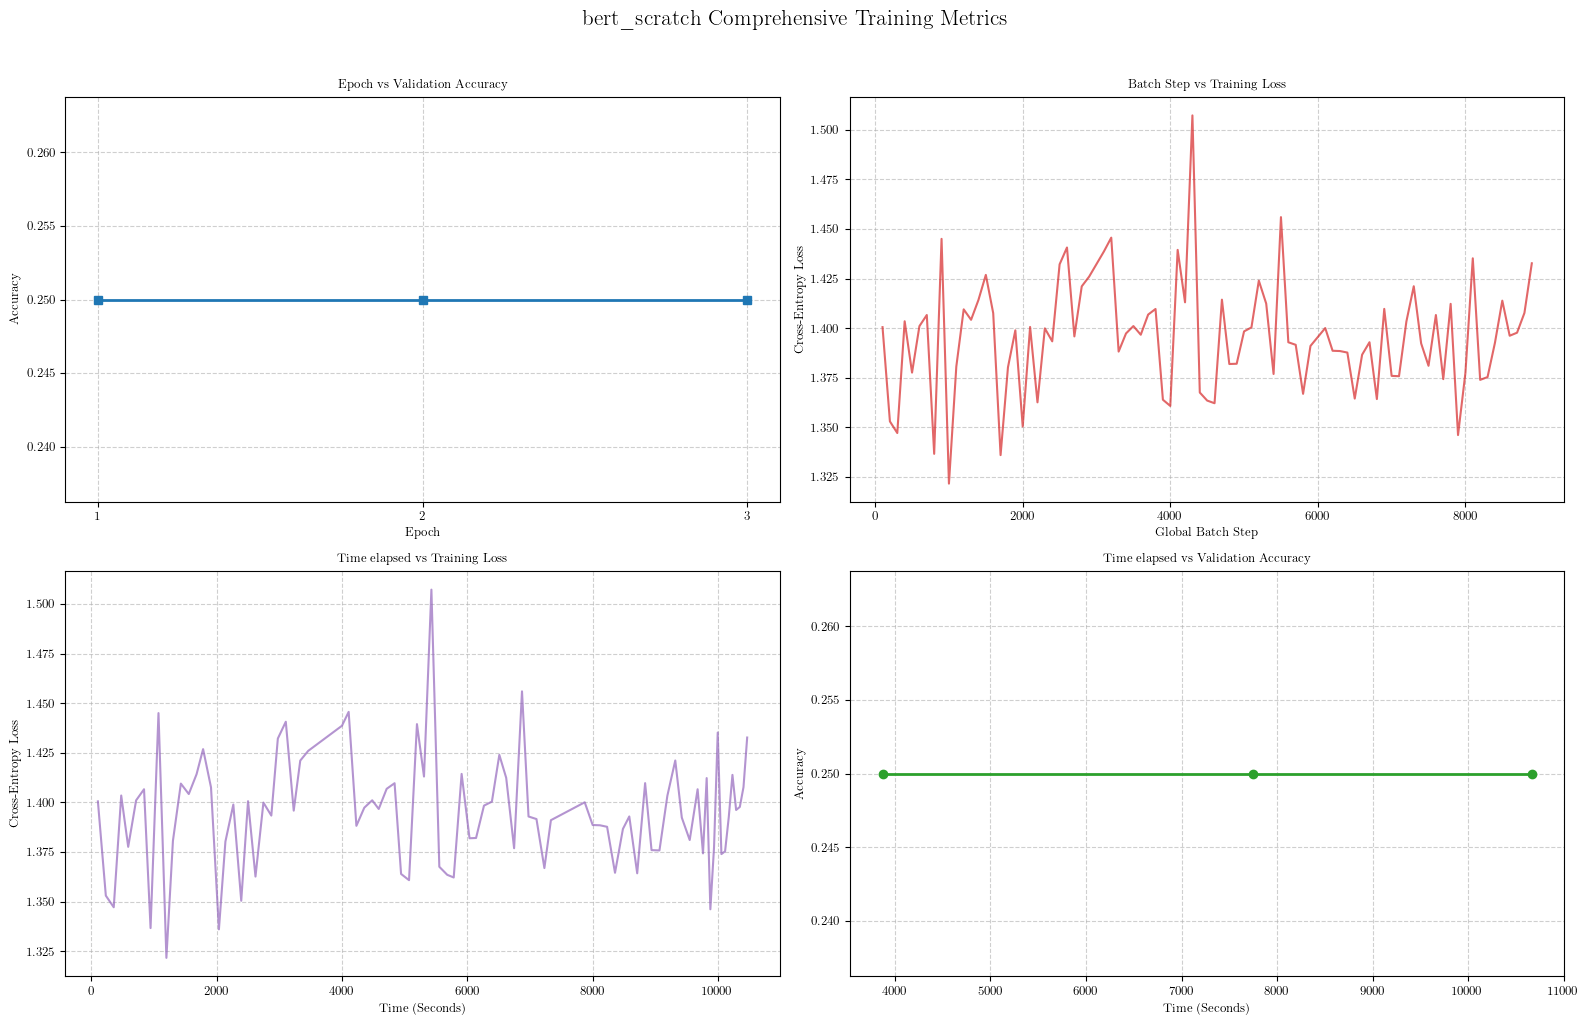


2) VALIDATION
Loaded validation run: metrics/bert_scratch_validation_run.npz

=== bert_scratch Validation Metrics ===
Accuracy:  0.2500
Precision: 0.0625
Recall:    0.2500
F1-Score:  0.1000

              precision    recall  f1-score   support

       World       0.00      0.00      0.00      6000
      Sports       0.25      1.00      0.40      6000
    Business       0.00      0.00      0.00      6000
    Sci/Tech       0.00      0.00      0.00      6000

    accuracy                           0.25     24000
   macro avg       0.06      0.25      0.10     24000
weighted avg       0.06      0.25      0.10     24000



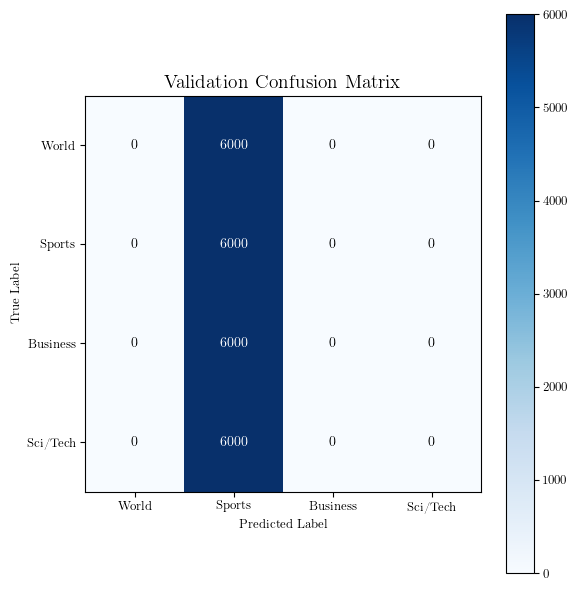


3) PROFILE SUMMARY

PROFILE SUMMARY: bert_scratch

[Model Architecture]
  Total Parameters:       109,485,316
  Trainable Parameters:   109,485,316
  Frozen Parameters:      0
  Trainable %:            100.0%
  Model Size:             417.66 MB

[Inference Performance on Validation Set]
  Inference Device:       cuda
  Total Inference Time:   287.67 seconds
  Samples Processed:      24,000
  Batches Processed:      750
  Throughput:             83.43 samples/sec
  Latency (per sample):   11.986 ms

[Overall Performance Metrics]
  Accuracy:               0.2500
  Precision (weighted):   0.0625
  Recall (weighted):      0.2500
  F1-Score (weighted):    0.1000

[Per-Class Breakdown]
  World        — Accuracy: 0.0000 | Support:  6000
  Sports       — Accuracy: 1.0000 | Support:  6000
  Business     — Accuracy: 0.0000 | Support:  6000
  Sci/Tech     — Accuracy: 0.0000 | Support:  6000

✓ Profile summary saved to: metrics/bert_scratch_profile_summary.json
Saved profile summary JSON: metrics

,Text,True Label,Predicted Label,Model Confidence
0,"wall street ' s designs on ' 05? a merger boom - after years of self - doubt and housecleaning in the wake of enron, corporate america has gotten a bit of swagger back in its step.",Business,Sports,28.7%
1,"olympians pursuit of marketing gold begins long before medals & lt ; b & gt ;... & lt ; / b & gt ; - for millions of americans, gymnast paul hamm # 39 ; s fame began only when the broad - shouldered olympian shrugged off a fall in the vaulting competition last week and made an inspired comeback to win gold.",Business,Sports,28.7%
2,"new device : flying robot - seiko epson hopes the tiny robot will help in security, disaster and rescue and space exploration. also : apple recalls batteries from its 15 - inch powerbook g4 laptops hellip ;. sony unveils eight new flat - screen tvs hellip ;. and more.",Business,Sports,28.7%
3,"spanish laureate ' was informer ' - prize - winning spanish writer camilo jose cela informed for general franco ' s regime, a historian says.",World,Sports,28.7%
4,"health highlights : aug. 17, 2004 - here are some of the latest health and medical news developments, compiled by editors of healthday : - - - - - arizona leads nation in west nile cases thousands of abandoned swimming pools, along with irrigation canals and other prime breeding sites for mosquitoes in phoenix, have made arizona the state hardest hit by west nile virus this year. arizona has accounted for at least 290 of more than 500 reported cases of west nile virus in the united states so far in 2004...",Sci/Tech,Sports,28.7%
5,"ambanis set up talks - nov. 21 : a family meeting of the ambanis is likely to take place tomorrow within hours of mukesh ambanis return from the us. in a tv interview aired a few days ago, mukesh had said there were ownership issues within the family.",Business,Sports,28.7%
6,"cisco revamps catalyst switch range - cisco today unveiled what it claimed is the world # 39 ; s first gigabit ethernet ( gbe ) enabled ip phone, in addition to a raft of enhancements to its catalyst switching range designed to boost security, availability and performance.",Sci/Tech,Sports,28.7%
7,"crawford financial resources inc - small wine producers seek supreme court # 39 ; s help in allowing them to make direct shipments to wine - lovers in other states. virginia wine makes a great holiday gift, but if the state # 39 ; s wineries send it to your",Business,Sports,28.7%
8,microsoft relents on office source code - microsoft will let governments access the computer code behind its office software as part of a broader campaign to provide alternatives to open - source applications.,Sci/Tech,Sports,28.7%
9,"us airways : the fliers amp ; stockholders - a us airways bankruptcy would reverberate in airline boardrooms, union halls and hangars around the country. what happens to the tickets you purchased for that fall",Business,Sports,28.7%


In [21]:
ultimate = run_ultimate_analysis(
    model=model_scratch,
    val_loader=val_loader,
    history=history_scratch,
    device=device,
    tokenizer=tokenizer,
    class_names=['World', 'Sports', 'Business', 'Sci/Tech'],
    model_name='bert_scratch',
    analysis_dir='metrics',
    force_validation_run=False,
    hardware_batches=5,
)

### Plotting

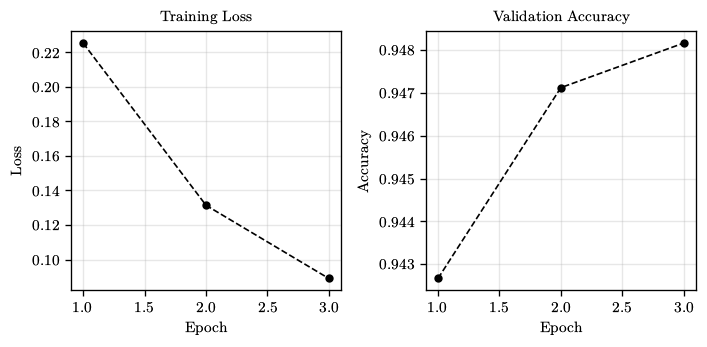

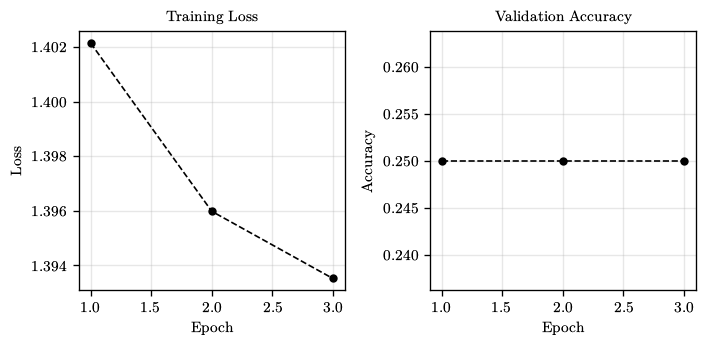

(<Figure size 720x360 with 2 Axes>,
 array([<Axes: title={'center': 'Training Loss'}, xlabel='Epoch', ylabel='Loss'>,
        <Axes: title={'center': 'Validation Accuracy'}, xlabel='Epoch', ylabel='Accuracy'>],
       dtype=object))

In [111]:
def load_history(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def plot_training_curves(
    history,
    train_loss_key,
    val_acc_key,
    save_path=None,
):
    train_loss = history[train_loss_key]
    val_acc = history[val_acc_key]
    epochs = range(1, len(train_loss) + 1)

    fig, axs = plt.subplots(1, 2, figsize=(6, 3))

    # Training loss
    axs[0].plot(epochs, train_loss, marker="o", linewidth=1, color="k", markersize=4, linestyle="--")
    axs[0].set_title("Training Loss")
    axs[0].set_xlabel("Epoch")
    axs[0].set_ylabel("Loss")
    axs[0].grid(True, alpha=0.3)

    # Validation accuracy
    axs[1].plot(epochs, val_acc, marker="o", linewidth=1, color="k", markersize=4, linestyle="--")
    axs[1].set_title("Validation Accuracy")
    axs[1].set_xlabel("Epoch")
    axs[1].set_ylabel("Accuracy")
    axs[1].grid(True, alpha=0.3)

    fig.tight_layout()

    fig.savefig(save_path, bbox_inches="tight")

    plt.show()
    return fig, axs


# Paths
pretrained_path = Path("metrics/bert_pretrained_history.json")
scratch_path = Path("metrics/bert_scratch_history.json")

# Load histories
history_pretrained = load_history(pretrained_path)
history_scratch = load_history(scratch_path)

# Plot pretrained model curves
plot_training_curves(
    history_pretrained,
    train_loss_key="train_loss_epoch",
    val_acc_key="val_accuracy_epoch",
    save_path="plots/pretrained_training_curves.pdf",
)

# Plot scratch model curves
plot_training_curves(
    history_scratch,
    train_loss_key="train_loss",
    val_acc_key="val_accuracy",
    save_path="plots/scratch_training_curves.pdf",
)

### Discussion of Results (Task 2b)

**1. Validation Accuracy (The Flat Line at 25%)**
The validation accuracy remained perfectly flat at exactly 0.250 (25%) across all three epochs. Because this dataset contains exactly 4 distinct classes (World, Sports, Business, Sci/Tech), an accuracy of 25% indicates that the model is performing no better than random guessing. It has not yet extracted enough semantic meaning from the text to successfully distinguish between the categories on unseen data.

**2. Training Loss (The Downward Trend)**
The training loss started around 1.402 and decreased slightly to 1.394. Mathematically, the expected cross-entropy loss for a model making random guesses across 4 classes is the natural logarithm of 4 ($\ln(4)$), which is approximately 1.386. The initial loss aligns perfectly with this theoretical baseline. Crucially, the steady downward trend in the training loss confirms that the model's architecture, loss function, and optimizer are all functioning correctly. The model *is* learning, but at an incredibly slow pace.

**3. The "From Scratch" Bottleneck**
These results are entirely expected and highlight the difficulty of training large language models. The BERT architecture contains roughly 110 million parameters. Because we initialized the model completely from scratch with random weights, it currently has no understanding of English grammar, vocabulary, or context. Three epochs on 96,000 samples is simply not enough time or data for a model of this magnitude to learn the entire English language from scratch *and* simultaneously optimize for a specialized categorization task.

**Conclusion:**
This baseline proves that while the PyTorch training loop and architecture are solid, training a massive Transformer from scratch is highly inefficient in terms of data, compute time, and hardware limitations. To achieve practical accuracy on this task without requiring weeks of dedicated GPU training, leveraging pre-trained contextual representations is absolutely necessary.

## Task 2c: Fine-Tuning a Pre-Trained Model

In Task 2b, we saw that training a 110-million parameter model from scratch takes an immense amount of time and data because the model starts with zero knowledge of language. 

In this task, we will apply **Transfer Learning**. We will load a version of BERT (`bert-base-uncased`) that has already been pre-trained by Google on an enormous corpus of text (English Wikipedia and BookCorpus). Because this model already deeply understands English syntax, grammar, and semantics, we only need to "fine-tune" it to map its existing knowledge to our 4 specific news categories.

### Dataset setup

In [13]:
# Load the data
df = pd.read_csv('train.csv', header=0, names=['ClassIndex', 'Title', 'Description'])

# Combine Title and Description
df['FullText'] = df['Title'] + " - " + df['Description']

# Ensure the column is integer type, then shift labels to be 0-indexed 
df['ClassIndex'] = df['ClassIndex'].astype(int) - 1 

# Split the data (80% train, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(
    df['FullText'].values, 
    df['ClassIndex'].values, 
    test_size=0.2, 
    random_state=42,
    stratify=df['ClassIndex'].values
)

print(f"Training samples: {len(X_train)} | Validation samples: {len(X_val)}")

# Setup Tokenizer and DataLoaders
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
train_dataset = NewsDataset(X_train, y_train, tokenizer, max_len=128)
val_dataset = NewsDataset(X_val, y_val, tokenizer, max_len=128)

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

Training samples: 96000 | Validation samples: 24000


### Training  

In [14]:
# Initialize the Model WITH PRE-TRAINED WEIGHTS
print("Downloading and loading pre-trained BERT weights:")
model_pretrained = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=4)
model_pretrained = model_pretrained.to(device)

# Setup the Optimizer
# We use a slightly lower learning rate (2e-5) so we don't aggressively overwrite the pre-trained weights.
optimizer_pretrained = AdamW(model_pretrained.parameters(), lr=2e-5)

# Train the model
# train_loader, val_loader, and the training function are reused from 2b
print("\nStarting Fine-Tuning...")
history_pretrained = train_and_evaluate_tracked(
    model=model_pretrained, 
    train_loader=train_loader,   # Reusing from Task 2b
    val_loader=val_loader,       # Reusing from Task 2b
    optimizer=optimizer_pretrained, 
    epochs=3,
    save_prefix="bert_pretrained"
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Starting Fine-Tuning...


NameError: name 'train_and_evaluate_tracked' is not defined

### Evaluation 

In [15]:
# Define paths
model_path = "weigths/bert_pretrained_epoch_3.pt" 
history_path = "metrics/bert_pretrained_history.json"
# Re-initialize the model architecture
print("Initializing BERT architecture...")
config = BertConfig.from_pretrained('bert-base-uncased', num_labels=4)
model_pretrained = BertForSequenceClassification(config)

# Load the saved weights
print(f"Loading weights from {model_path}...")
model_pretrained.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
model_pretrained = model_pretrained.to(device)
print("Loaded model to device {} successfully!".format(device))

# Load the training history
try:
    with open(history_path, "r") as f:
        history_pretrained = json.load(f)
    print("Model and history loaded successfully!")
except:
    print(f"Could not find {history_path}.")

Initializing BERT architecture...
Loading weights from weigths/bert_pretrained_epoch_3.pt...
Loaded model to device cuda successfully!
Model and history loaded successfully!


In [16]:
evaluator = UniversalEvaluator(model=model_pretrained, device=device, 
                               tokenizer=tokenizer, 
                               class_names=['World', 'Sports', 'Business', 'Sci/Tech'])
pred = evaluator.predict_text("This Date in Baseball (AP),AP - 1934  #151; Daffy Dean of the St. Louis Cardinals pitched a no-hitter against the Brooklyn Dodgers for 3-0 victory in the second game of an Ebbets Field doubleheader. Daffy's brother, Dizzy, held Brooklyn hitless for eight innings in the opener and won 13-0.")
print(pred)

{'predicted_index': 1, 'predicted_label': 'Sports', 'confidence': 0.9998526573181152, 'probabilities': {'World': 9.906497871270403e-05, 'Sports': 0.9998526573181152, 'Business': 2.417749783489853e-05, 'Sci/Tech': 2.407522151770536e-05}}



ULTIMATE ANALYSIS: bert_pretrained

1) TRAINING HISTORY
=== Training History Analysis: bert_pretrained ===

[Speed & Duration]
Total Training Time: 215.49 minutes
Average Epoch Time:  4309.75 seconds
Average Batch Time:  1462.27 ms
Training Throughput: 0.68 batches / second

[Performance Highlights]
Best Val Accuracy:   0.9482 (Achieved in Epoch 3)
Best Val F1-Score:   0.9482 (Achieved in Epoch 3)
Lowest Val Loss:     0.1581 (Achieved in Epoch 2)


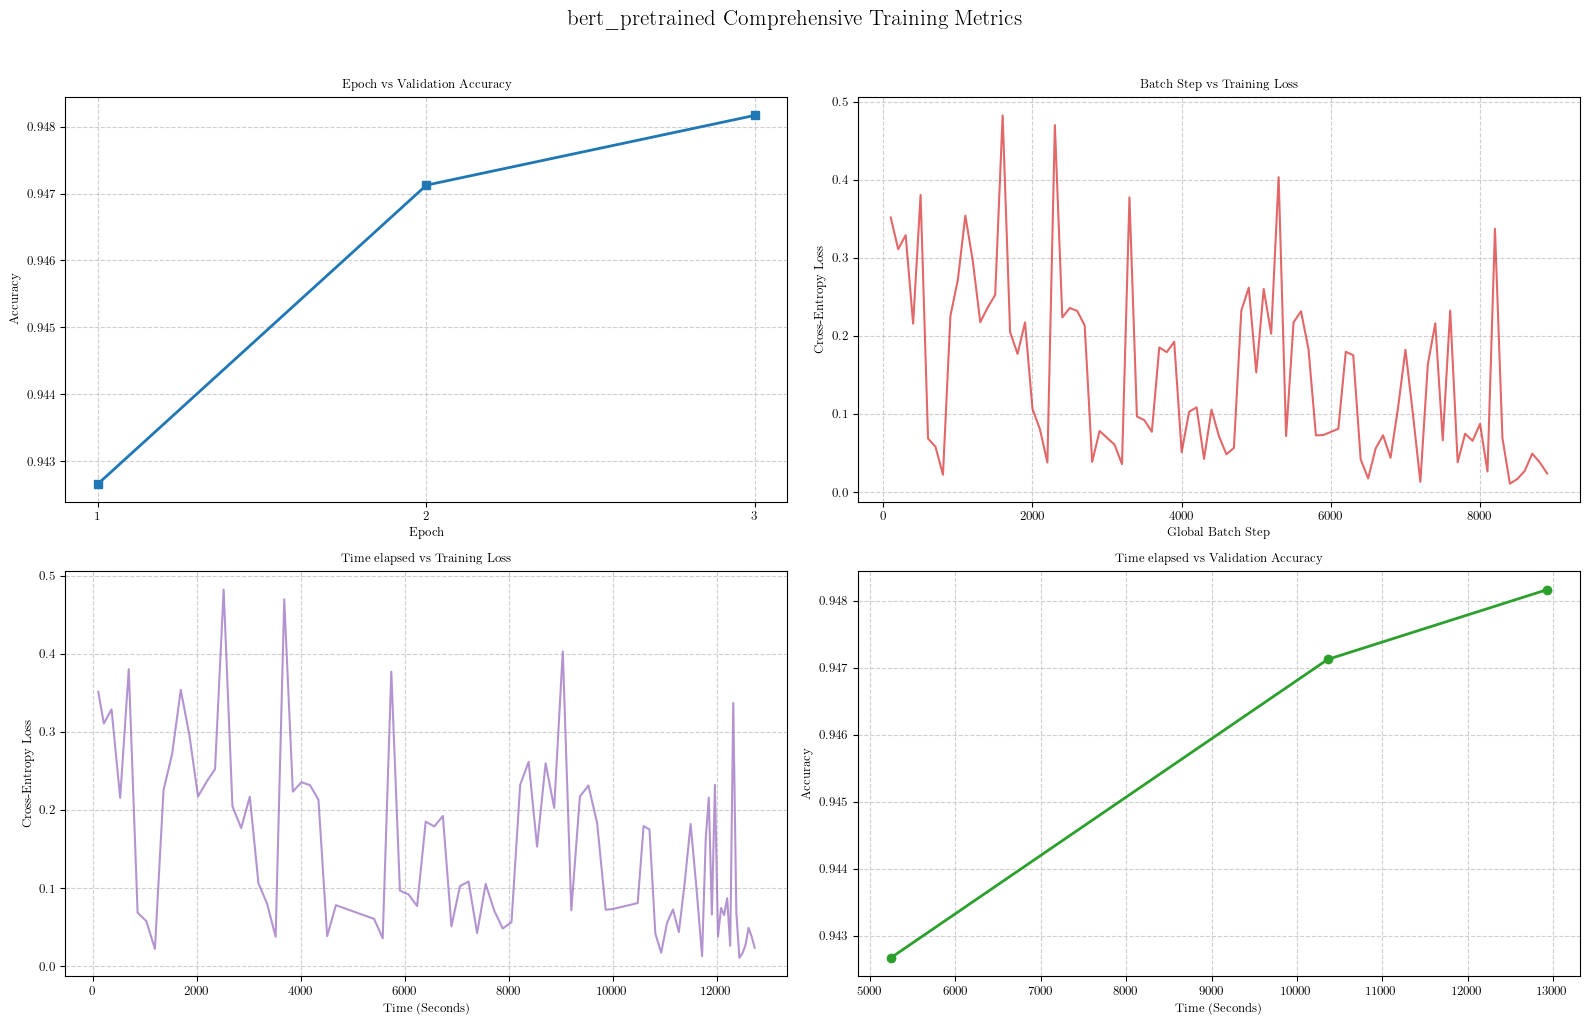


2) VALIDATION
Loaded validation run: metrics/bert_pretrained_validation_run.npz

=== bert_pretrained Validation Metrics ===
Accuracy:  0.9482
Precision: 0.9483
Recall:    0.9482
F1-Score:  0.9482

              precision    recall  f1-score   support

       World       0.97      0.94      0.96      6000
      Sports       0.98      0.99      0.99      6000
    Business       0.92      0.92      0.92      6000
    Sci/Tech       0.92      0.94      0.93      6000

    accuracy                           0.95     24000
   macro avg       0.95      0.95      0.95     24000
weighted avg       0.95      0.95      0.95     24000



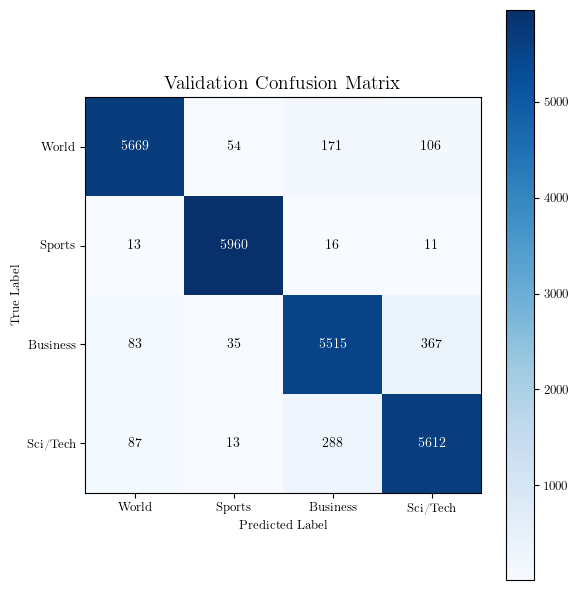


3) PROFILE SUMMARY

PROFILE SUMMARY: bert_pretrained

[Model Architecture]
  Total Parameters:       109,485,316
  Trainable Parameters:   109,485,316
  Frozen Parameters:      0
  Trainable %:            100.0%
  Model Size:             417.66 MB

[Inference Performance on Validation Set]
  Inference Device:       cuda
  Total Inference Time:   295.93 seconds
  Samples Processed:      24,000
  Batches Processed:      750
  Throughput:             81.10 samples/sec
  Latency (per sample):   12.331 ms

[Overall Performance Metrics]
  Accuracy:               0.9482
  Precision (weighted):   0.9483
  Recall (weighted):      0.9482
  F1-Score (weighted):    0.9482

[Per-Class Breakdown]
  World        — Accuracy: 0.9448 | Support:  6000
  Sports       — Accuracy: 0.9933 | Support:  6000
  Business     — Accuracy: 0.9192 | Support:  6000
  Sci/Tech     — Accuracy: 0.9353 | Support:  6000

✓ Profile summary saved to: metrics/bert_pretrained_profile_summary.json
Saved profile summary JSON: m

,Text,True Label,Predicted Label,Model Confidence
0,"nextel wants better fcc deal - nextel communications inc. is pressing the federal communications commission to revamp its controversial decision giving the cellular company new airwaves, seeking changes that according to",Sci/Tech,Business,59.7%
1,"intel puts its weight behind symbian - intel is building a symbian - based mobile phone, based on nokia # 39 ; s series 60 user interface. the company has not announced a delivery date, but a reference platform should arrive sometime in 2005, intended to",Business,Sci/Tech,89.5%
2,stakes high for england - england will have a semi - final place in their sights when they face sri lanka in the champions trophy.,World,Sports,99.9%
3,"microsoft still wants eu settlement ( reuters ) - reuters - microsoft corp ' s chief counsel, \ briefing reporters in the lead - up to a european union court \ hearing this week, said on monday he remains hopeful the \ software giant ' s european antitrust case can be settled.",Business,Sci/Tech,48.9%
4,"military snipers learn from competition ( ap ) - ap - corp. eugenio mendoza, a young veteran of the iraq war, had to carry his buddy for 50 yards, scale an 8 - foot wall and crawl through a water - logged tunnel at the 4th international sniper competition, where the challenges are designed to simulate combat scenarios in afghanistan and iraq.",Sports,World,92.5%
5,un urged to ignore bush plea for human cloning ban ( reuters ) - reuters - britain ' s national academy of science \ urged the united nations on monday to ignore a call by \ president bush to ban all forms of human cloning.,World,Sci/Tech,58.0%
6,"fcc denies states control of voip - providers of internet - based phone services, such as overland park - based nuvio corp. and time warner cable, notched a victory tuesday when the federal communications commission said states could not regulate the futuristic service.",Business,Sci/Tech,51.3%
7,"aerosols ' harm mother and baby ' - air fresheners and aerosols can damage of the health of babies and their mothers, warn researchers.",World,Sci/Tech,70.4%
8,"the more the red sox and cubs talk about it, the worse it gets - i # 39 ; m pleased to report that you # 39 ; ve heeded my anguished cry for thoughtful commentary and staved off my insidious plan to write a treatise on keynesian economics.",Sports,Business,97.7%
9,"takenaka says tankan confirms japan # 39 ; s steady economic recovery - the bank of japan # 39 ; s quarterly survey of business confidence confirmed that the world # 39 ; s second - largest economy is recovering at a steady pace, economic and fiscal policy minister heizo takenaka said.",World,Business,81.8%


In [19]:
ultimate = run_ultimate_analysis(
    model=model_pretrained,
    val_loader=val_loader,
    history=history_pretrained,
    device=device,
    tokenizer=tokenizer,
    class_names=['World', 'Sports', 'Business', 'Sci/Tech'],
    model_name='bert_pretrained',
    analysis_dir='metrics',
    force_validation_run=False,
    hardware_batches=10,
)


ULTIMATE ANALYSIS: bert_pretrained

1) TRAINING HISTORY
=== Training History Analysis: bert_pretrained ===

[Speed & Duration]
Total Training Time: 215.49 minutes
Average Epoch Time:  4309.75 seconds
Average Batch Time:  1462.27 ms
Training Throughput: 0.68 batches / second

[Performance Highlights]
Best Val Accuracy:   0.9482 (Achieved in Epoch 3)
Best Val F1-Score:   0.9482 (Achieved in Epoch 3)
Lowest Val Loss:     0.1581 (Achieved in Epoch 2)


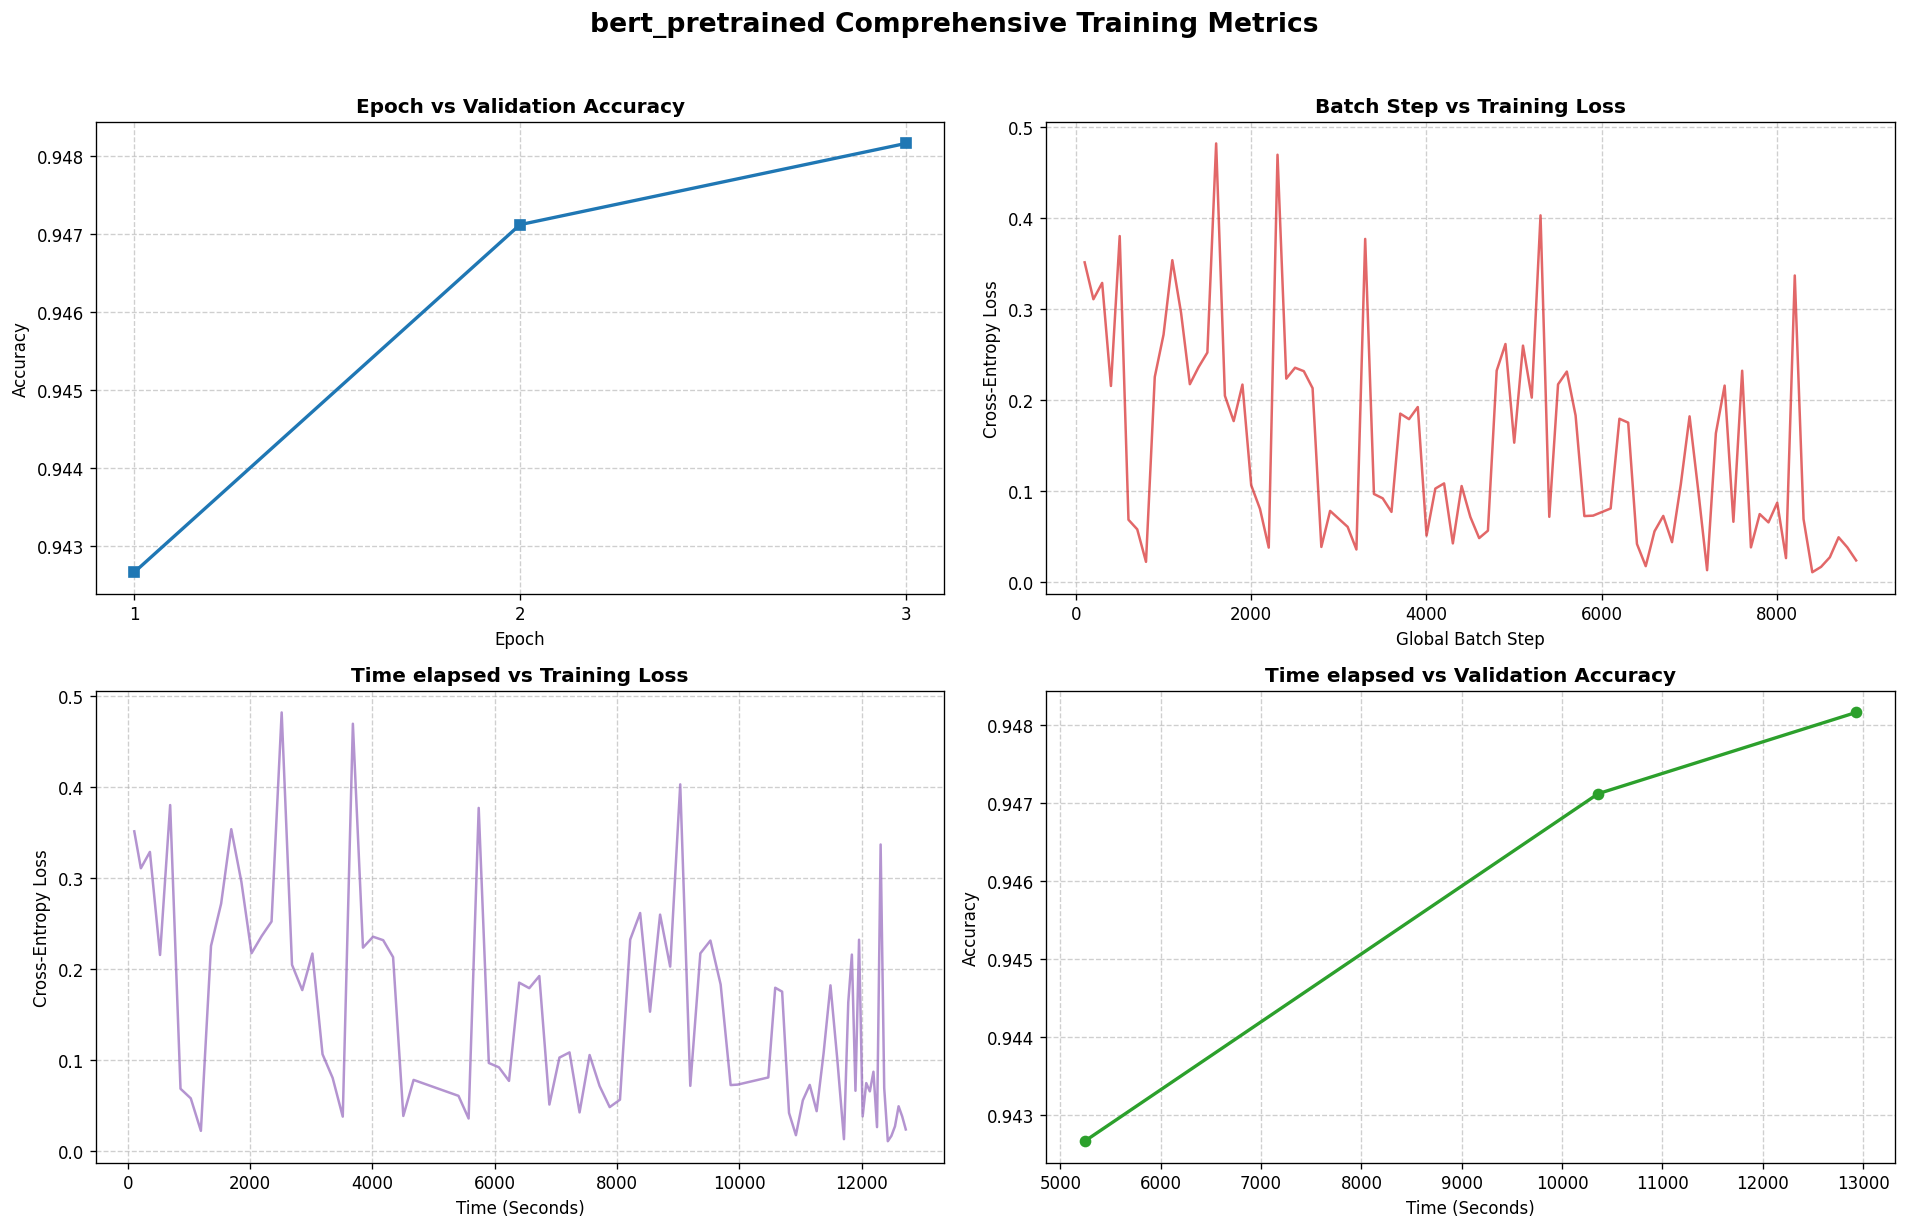


2) VALIDATION
Loaded validation run: metrics\bert_pretrained_validation_run.npz

=== bert_pretrained Validation Metrics ===
Accuracy:  0.9482
Precision: 0.9483
Recall:    0.9482
F1-Score:  0.9482

              precision    recall  f1-score   support

       World       0.97      0.94      0.96      6000
      Sports       0.98      0.99      0.99      6000
    Business       0.92      0.92      0.92      6000
    Sci/Tech       0.92      0.94      0.93      6000

    accuracy                           0.95     24000
   macro avg       0.95      0.95      0.95     24000
weighted avg       0.95      0.95      0.95     24000



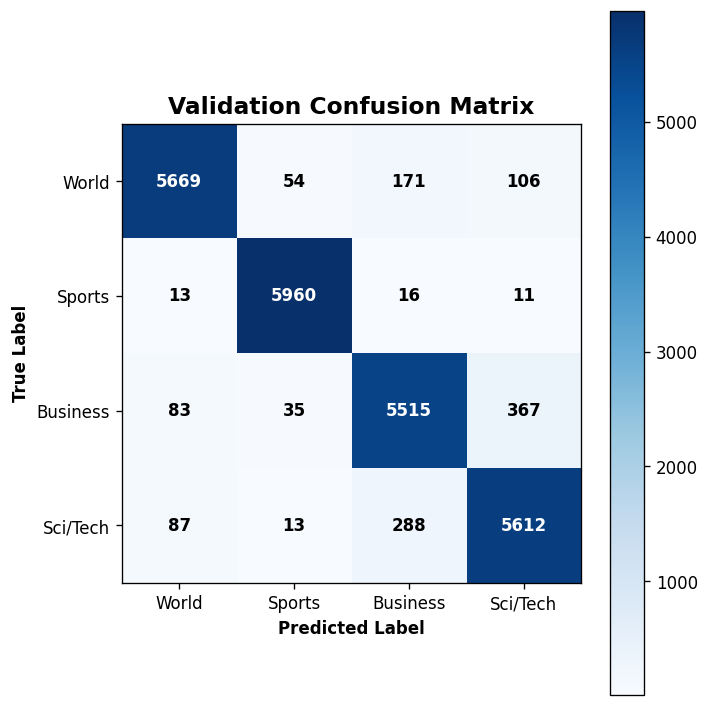


3) PROFILE SUMMARY

PROFILE SUMMARY: bert_pretrained

[Model Architecture]
  Total Parameters:       109,485,316
  Trainable Parameters:   109,485,316
  Frozen Parameters:      0
  Trainable %:            100.0%
  Model Size:             417.66 MB

[Inference Performance on Validation Set]
  Inference Device:       cuda
  Total Inference Time:   295.93 seconds
  Samples Processed:      24,000
  Batches Processed:      750
  Throughput:             81.10 samples/sec
  Latency (per sample):   12.331 ms

[Overall Performance Metrics]
  Accuracy:               0.9482
  Precision (weighted):   0.9483
  Recall (weighted):      0.9482
  F1-Score (weighted):    0.9482

[Per-Class Breakdown]
  World        — Accuracy: 0.9448 | Support:  6000
  Sports       — Accuracy: 0.9933 | Support:  6000
  Business     — Accuracy: 0.9192 | Support:  6000
  Sci/Tech     — Accuracy: 0.9353 | Support:  6000

✓ Profile summary saved to: metrics\bert_pretrained_profile_summary.json
Saved profile summary JSON: m

In [40]:
ultimate = run_ultimate_analysis(
    model=model_pretrained,
    val_loader=val_loader,
    history=history_pretrained,
    device=device,
    tokenizer=tokenizer,
    class_names=['World', 'Sports', 'Business', 'Sci/Tech'],
    model_name='bert_pretrained',
    analysis_dir='metrics',
    force_validation_run=False,
    hardware_batches=10,
)       

### Plotting

In [ ]:
evaluator = UniversalEvaluator(model=model_pretrained, device=device, tokenizer=tokenizer, class_names=['World', 'Sports', 'Business', 'Sci/Tech'])
run_object = evaluator.run_validation(
val_loader=val_loader,
run_path='metrics/bert_pretrained_validation_run.npz',
)

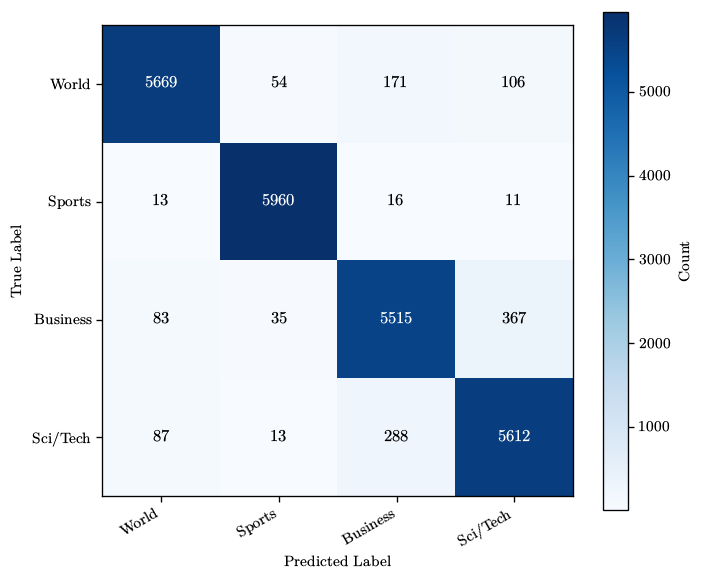

In [97]:
cm = evaluator.confusion(run_object)
class_names = evaluator.class_names

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
cbar = fig.colorbar(im, ax=ax)
cbar.ax.set_ylabel('Count', rotation=90, va='center', labelpad=10)

ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names, rotation=30, ha='right')
ax.set_yticklabels(class_names)

threshold = cm.max() / 2.0 if cm.size else 0.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, f'{cm[i, j]}', ha='center', va='center', color='white' if cm[i, j] > threshold else 'black', fontweight='bold')

ax.grid(False)
fig.tight_layout()

fig.savefig('plots/confusion_matrix_bert_pretrained.pdf', bbox_inches='tight')
plt.show()

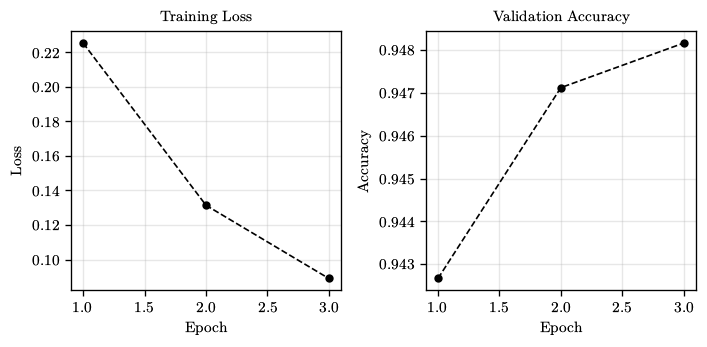

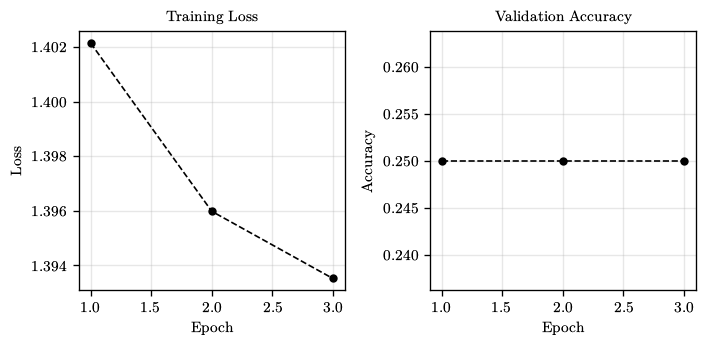

In [113]:
def load_history(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def plot_training_curves(
    history,
    train_loss_key,
    val_acc_key,
    save_path=None,
):
    train_loss = history[train_loss_key]
    val_acc = history[val_acc_key]
    epochs = range(1, len(train_loss) + 1)

    fig, axs = plt.subplots(1, 2, figsize=(6, 3))

    # Training loss
    axs[0].plot(epochs, train_loss, marker="o", linewidth=1, color="k", markersize=4, linestyle="--")
    axs[0].set_title("Training Loss")
    axs[0].set_xlabel("Epoch")
    axs[0].set_ylabel("Loss")
    axs[0].grid(True, alpha=0.3)

    # Validation accuracy
    axs[1].plot(epochs, val_acc, marker="o", linewidth=1, color="k", markersize=4, linestyle="--")
    axs[1].set_title("Validation Accuracy")
    axs[1].set_xlabel("Epoch")
    axs[1].set_ylabel("Accuracy")
    axs[1].grid(True, alpha=0.3)

    fig.tight_layout()

    fig.savefig(save_path, bbox_inches="tight")

    plt.show()


# Paths
pretrained_path = Path("metrics/bert_pretrained_history.json")
scratch_path = Path("metrics/bert_scratch_history.json")

# Load histories
history_pretrained = load_history(pretrained_path)
history_scratch = load_history(scratch_path)

# Plot pretrained model curves
plot_training_curves(
    history_pretrained,
    train_loss_key="train_loss_epoch",
    val_acc_key="val_accuracy_epoch",
    save_path="plots/pretrained_training_curves.pdf",
)

# Plot scratch model curves
plot_training_curves(
    history_scratch,
    train_loss_key="train_loss",
    val_acc_key="val_accuracy",
    save_path="plots/scratch_training_curves.pdf",
)

## Task 2d: Representation extraction and visualization

In [20]:
evaluator = UniversalEvaluator(model=model_pretrained, device=device, tokenizer=tokenizer, class_names=['World', 'Sports', 'Business', 'Sci/Tech'])
class_names = ['World', 'Sports', 'Business', 'Sci/Tech']
layers_to_plot = [-4, -3, -2, -1]

# Calculated representations save path. It is computationally expensive to run the model and t-SNE...
cache_filepath = "metrics/tsne_representations.npz"

if os.path.exists(cache_filepath):
    print("Cache found! Loading...")
    reduced_embeddings_dict, true_labels = evaluator.load_reduced_embeddings(cache_filepath)
else:
    print("No cache found. Running model and t-SNE computations...")
    
    # Extract high-dimensional data
    embeddings_dict, true_labels, _ = evaluator.extract_representations(
        model=model_pretrained,
        dataloader=val_loader,
        device=device,
        target_layers=layers_to_plot,
        num_batches=25
    )
    
    # Run t-SNE for each layer
    reduced_embeddings_dict = {}
    for layer_idx in layers_to_plot:
        print(f"  Running t-SNE reduction for Layer {layer_idx}...")
        high_dim_data = embeddings_dict[layer_idx]
        reduced_embeddings_dict[layer_idx] = evaluator.reduce_dimensions(high_dim_data, method='tsne')
        
    # Save the results
    evaluator.save_reduced_embeddings(cache_filepath, reduced_embeddings_dict, true_labels)

No cache found. Running model and t-SNE computations...
Running forward pass to extract layers: [-4, -3, -2, -1] for 25 batches...
  Processed 2/25 batches
  Processed 4/25 batches
  Processed 6/25 batches
  Processed 8/25 batches
  Processed 10/25 batches
  Processed 12/25 batches
  Processed 14/25 batches
  Processed 16/25 batches
  Processed 18/25 batches
  Processed 20/25 batches
  Processed 22/25 batches
  Processed 24/25 batches
Successfully extracted representations from 25 batches.
  Running t-SNE reduction for Layer -4...
  Running t-SNE reduction for Layer -3...
  Running t-SNE reduction for Layer -2...
  Running t-SNE reduction for Layer -1...
Successfully saved reduced embeddings to metrics/tsne_representations.npz


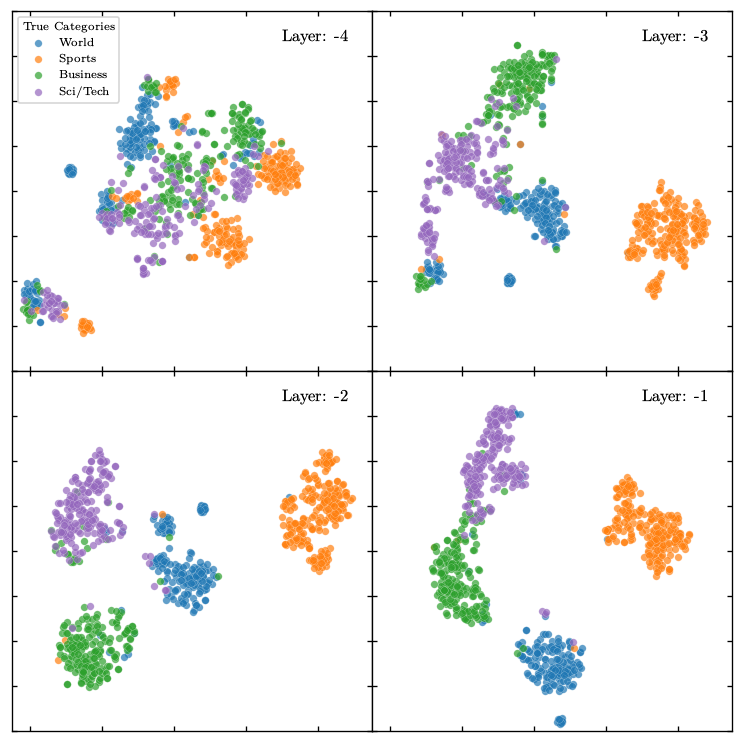

In [87]:
# Setup the Matplotlib Figure
fig, axs = plt.subplots(2, 2, figsize=(6, 6))
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:purple']

# Process and Plot Each Layer
for idx, layer_idx in enumerate(layers_to_plot):
    # Retrieve the 2D data directly from dictionary
    embeddings_2d = reduced_embeddings_dict[layer_idx]
    
    # Determine which subplot to draw on
    row = idx // 2
    col = idx % 2
    ax = axs[row, col]
    
    # Draw the points for each category
    for class_idx, class_name in enumerate(class_names):
        point_mask = (true_labels == class_idx)
        
        ax.scatter(
            embeddings_2d[point_mask, 0], 
            embeddings_2d[point_mask, 1], 
            c=colors[class_idx], 
            label=class_name, 
            alpha=0.7, 
            edgecolors='w', 
            linewidth=0.15,
            s=20
        )
        
    # Formatting for this specific subplot
    # Show tick marks but hide labels, and draw ticks on the inside
    ax.set_xlim(-45,55)
    ax.set_ylim(-40,40)
    ax.tick_params(axis='both', which='both', labelbottom=False, labelleft=False, direction='in', length=3, right=True, top=True)

    # Put the layer number inside the plot (top-left)
    ax.text(.75, 0.95, f'Layer: {layer_idx}', transform=ax.transAxes, ha='left', va='top', fontsize=10)
    
    if idx == 0: 
        ax.legend(title="True Categories", loc='best', fontsize=7, title_fontsize=7)

plt.tight_layout()

# Make the subplots touch by removing spacing
plt.tight_layout(pad=0)
plt.subplots_adjust(wspace=0, hspace=0)

plt.savefig("plots/tsne_representations.pdf", bbox_inches='tight')
plt.show()

## Task 2e: layer reduction

In [18]:
import copy

def create_pruned_bert(num_layers_to_keep=6, num_labels=4):
    """
    Initializes a fresh BERT model and drops the top layers.
    Returns a smaller, faster model ready for fine-tuning.
    """
    print(f"Loading base BERT and pruning down to {num_layers_to_keep} layers...")
    
    # pre-trained BERT configuration and model
    config = BertConfig.from_pretrained('bert-base-uncased', num_labels=num_labels)
    full_model = BertForSequenceClassification.from_pretrained('bert-base-uncased', config=config)
    
    # Slice the encoder layers
    # The layers are stored in a standard PyTorch nn.ModuleList
    # We keep from index 0 up to num_layers_to_keep
    full_model.bert.encoder.layer = full_model.bert.encoder.layer[:num_layers_to_keep]
    
    # Update the configuration to reflect the new architecture
    full_model.config.num_hidden_layers = num_layers_to_keep
    
    # Count the parameters to prove we shrank it
    total_params = sum(p.numel() for p in full_model.parameters())
    print(f"Pruning successful! New parameter count: {total_params:,}")
    
    return full_model

def load_pruned_bert_model(checkpoint_path, num_layers_to_keep, num_labels=4):
    """Load a pruned BERT checkpoint onto the active device."""
    model = create_pruned_bert(num_layers_to_keep=num_layers_to_keep, num_labels=num_labels)
    state_dict = torch.load(checkpoint_path, map_location=device, weights_only=True)
    model.load_state_dict(state_dict)
    model = model.to(device)
    model.eval()
    return model

### Dataset setup

In [14]:
# Load the data
df = pd.read_csv('train.csv', header=0, names=['ClassIndex', 'Title', 'Description'])

# Combine Title and Description
df['FullText'] = df['Title'] + " - " + df['Description']

# Ensure the column is integer type, then shift labels to be 0-indexed 
df['ClassIndex'] = df['ClassIndex'].astype(int) - 1 

# Split the data (80% train, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(
    df['FullText'].values, 
    df['ClassIndex'].values, 
    test_size=0.2, 
    random_state=42,
    stratify=df['ClassIndex'].values
)

print(f"Training samples: {len(X_train)} | Validation samples: {len(X_val)}")

# Setup Tokenizer and DataLoaders
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
train_dataset = NewsDataset(X_train, y_train, tokenizer, max_len=128)
val_dataset = NewsDataset(X_val, y_val, tokenizer, max_len=128)

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

Training samples: 96000 | Validation samples: 24000


### Training

#### 6 Layers

In [24]:
# Create the 6-layer model and push it to the GPU
model_pruned = create_pruned_bert(num_layers_to_keep=6, num_labels=4)
model_pruned = model_pruned.to(device)

# Set up the optimizer (using the same learning rate as Task 2c for a fair comparison)
optimizer_pruned = AdamW(model_pruned.parameters(), lr=2e-5)

# Fine-tune the pruned model
history_pruned_6L = train_and_evaluate_tracked(
    model=model_pruned, 
    train_loader=train_loader,   
    val_loader=val_loader,       
    optimizer=optimizer_pruned, 
    epochs=3,
    save_prefix="weigths/bert_pruned_6L" 
)


Loading base BERT and pruning down to 6 layers...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Pruning successful! New parameter count: 66,958,084

Epoch 1/3
-----------------------------------
  Batch 100/3000 | Loss: 0.1934 | Time: 28.0s
  Batch 200/3000 | Loss: 0.0772 | Time: 56.5s
  Batch 300/3000 | Loss: 0.3808 | Time: 85.6s
  Batch 400/3000 | Loss: 0.1542 | Time: 115.0s
  Batch 500/3000 | Loss: 0.3588 | Time: 144.8s
  Batch 600/3000 | Loss: 0.1500 | Time: 174.8s
  Batch 700/3000 | Loss: 0.1801 | Time: 205.2s
  Batch 800/3000 | Loss: 0.2476 | Time: 235.6s
  Batch 900/3000 | Loss: 0.2137 | Time: 266.2s
  Batch 1000/3000 | Loss: 0.2868 | Time: 297.0s
  Batch 1100/3000 | Loss: 0.1674 | Time: 327.9s
  Batch 1200/3000 | Loss: 0.4613 | Time: 358.9s
  Batch 1300/3000 | Loss: 0.1311 | Time: 390.1s
  Batch 1400/3000 | Loss: 0.0431 | Time: 421.4s
  Batch 1500/3000 | Loss: 0.2637 | Time: 452.7s
  Batch 1600/3000 | Loss: 0.3501 | Time: 484.0s
  Batch 1700/3000 | Loss: 0.1360 | Time: 515.4s
  Batch 1800/3000 | Loss: 0.1577 | Time: 546.9s
  Batch 1900/3000 | Loss: 0.1871 | Time: 578.3s
 


ULTIMATE ANALYSIS: bert_pruned_6L

1) TRAINING HISTORY
=== Training History Analysis: bert_pruned_6L ===

[Speed & Duration]
Total Training Time: 50.84 minutes
Average Epoch Time:  1016.73 seconds
Average Batch Time:  337.56 ms
Training Throughput: 2.96 batches / second

[Performance Highlights]
Best Val Accuracy:   0.9473 (Achieved in Epoch 2)
Best Val F1-Score:   0.9472 (Achieved in Epoch 2)
Lowest Val Loss:     0.1590 (Achieved in Epoch 2)


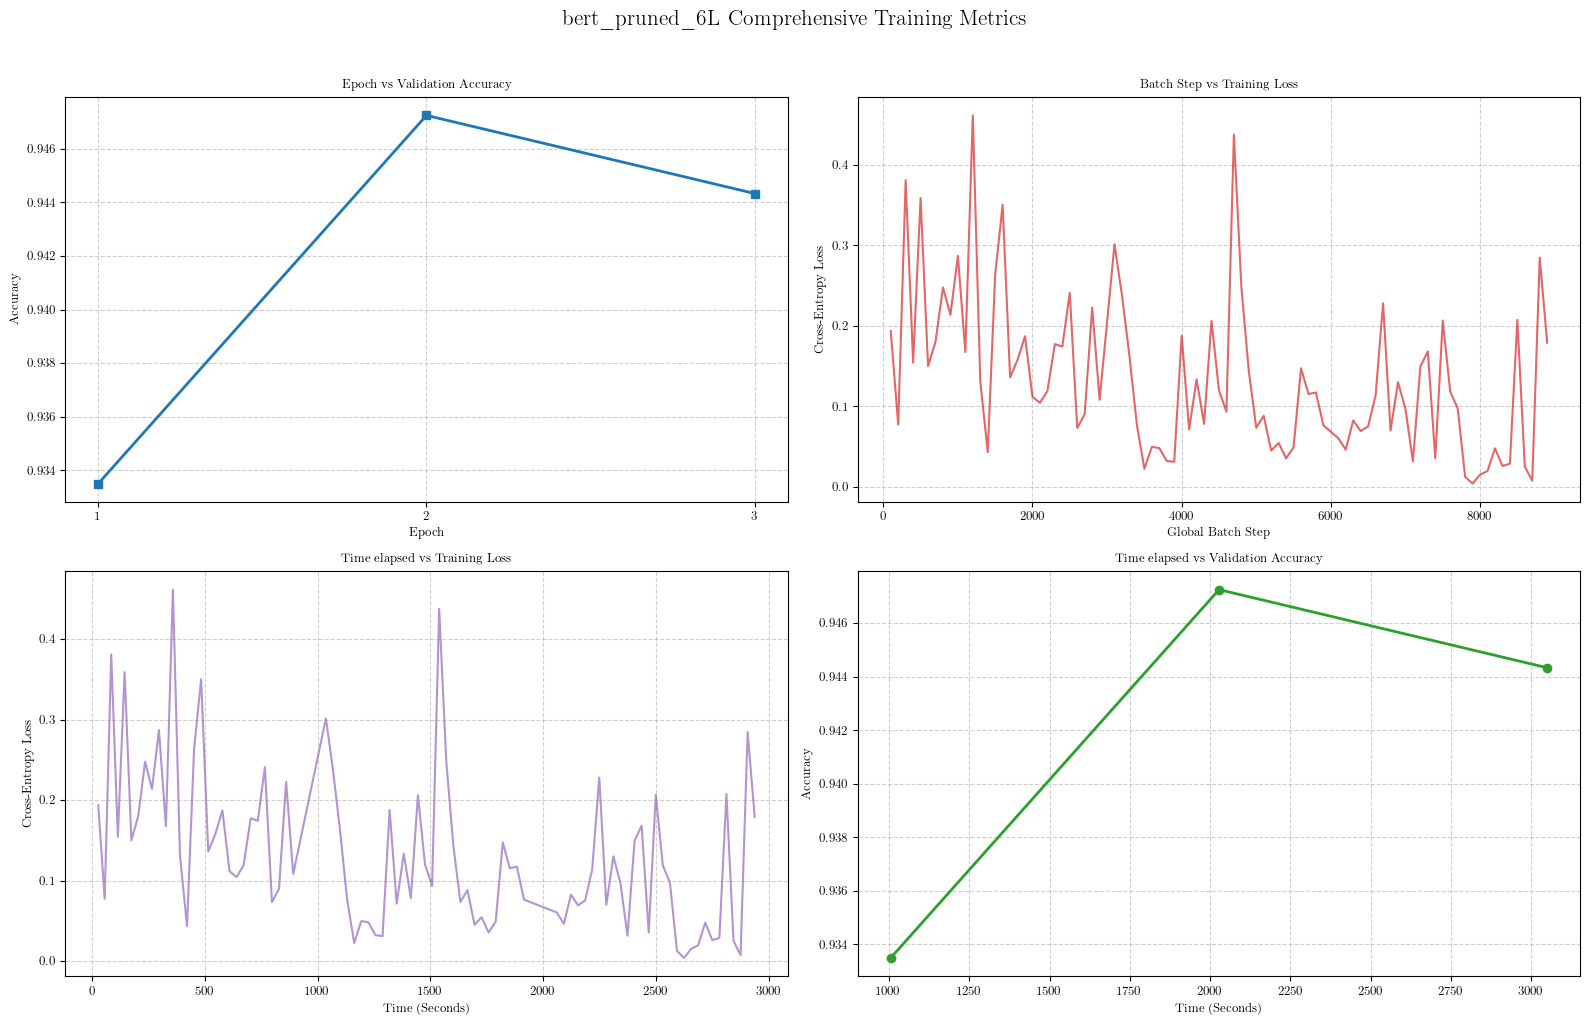


2) VALIDATION
Saved validation run: metrics/bert_pruned_6l_validation_run.npz

=== bert_pruned_6L Validation Metrics ===
Accuracy:  0.9443
Precision: 0.9446
Recall:    0.9443
F1-Score:  0.9443

              precision    recall  f1-score   support

       World       0.97      0.93      0.95      6000
      Sports       0.97      0.99      0.98      6000
    Business       0.91      0.92      0.92      6000
    Sci/Tech       0.92      0.93      0.92      6000

    accuracy                           0.94     24000
   macro avg       0.94      0.94      0.94     24000
weighted avg       0.94      0.94      0.94     24000



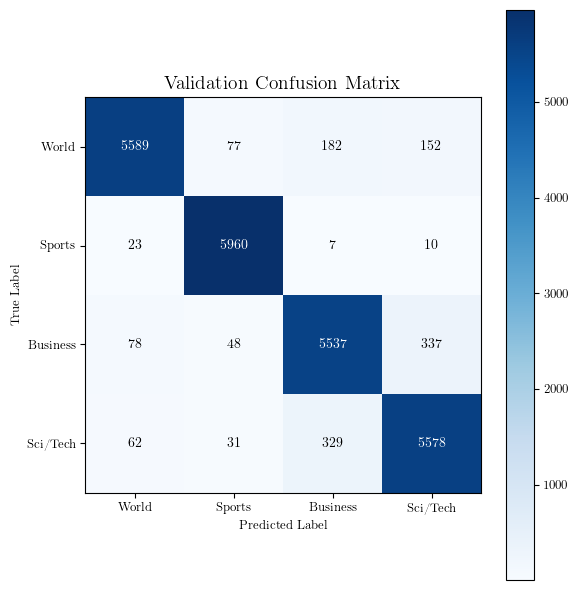


3) PROFILE SUMMARY

PROFILE SUMMARY: bert_pruned_6L

[Model Architecture]
  Total Parameters:       66,958,084
  Trainable Parameters:   66,958,084
  Frozen Parameters:      0
  Trainable %:            100.0%
  Model Size:             255.43 MB

[Inference Performance on Validation Set]
  Inference Device:       cuda
  Total Inference Time:   80.12 seconds
  Samples Processed:      24,000
  Batches Processed:      750
  Throughput:             299.54 samples/sec
  Latency (per sample):   3.338 ms

[Overall Performance Metrics]
  Accuracy:               0.9443
  Precision (weighted):   0.9446
  Recall (weighted):      0.9443
  F1-Score (weighted):    0.9443

[Per-Class Breakdown]
  World        — Accuracy: 0.9315 | Support:  6000
  Sports       — Accuracy: 0.9933 | Support:  6000
  Business     — Accuracy: 0.9228 | Support:  6000
  Sci/Tech     — Accuracy: 0.9297 | Support:  6000

✓ Profile summary saved to: metrics/bert_pruned_6l_profile_summary.json
Saved profile summary JSON: metric

,Text,True Label,Predicted Label,Model Confidence
0,"nextel wants better fcc deal - nextel communications inc. is pressing the federal communications commission to revamp its controversial decision giving the cellular company new airwaves, seeking changes that according to",Sci/Tech,Business,85.2%
1,"sun, kodak look to future following patent suit settlement - in lieu of facing a court judgment of possibly more than us \ $ 1 billion, sun microsystems has agreed to pay \ $ 92 million to settle a long - running patent infringement case with eastman kodak.",Sci/Tech,Business,76.7%
2,"intel puts its weight behind symbian - intel is building a symbian - based mobile phone, based on nokia # 39 ; s series 60 user interface. the company has not announced a delivery date, but a reference platform should arrive sometime in 2005, intended to",Business,Sci/Tech,95.5%
3,"microsoft still wants eu settlement ( reuters ) - reuters - microsoft corp ' s chief counsel, \ briefing reporters in the lead - up to a european union court \ hearing this week, said on monday he remains hopeful the \ software giant ' s european antitrust case can be settled.",Business,Sci/Tech,77.4%
4,"military snipers learn from competition ( ap ) - ap - corp. eugenio mendoza, a young veteran of the iraq war, had to carry his buddy for 50 yards, scale an 8 - foot wall and crawl through a water - logged tunnel at the 4th international sniper competition, where the challenges are designed to simulate combat scenarios in afghanistan and iraq.",Sports,Sci/Tech,70.5%
5,un urged to ignore bush plea for human cloning ban ( reuters ) - reuters - britain ' s national academy of science \ urged the united nations on monday to ignore a call by \ president bush to ban all forms of human cloning.,World,Sci/Tech,91.2%
6,"study : j amp ; j neck stent is as effective as surgery - johnson amp ; johnson ' s neck stent is as effective as surgery in clearing blocked blood vessels to the brain that can cause strokes and death, according to a company - funded study in tomorrow ' s new england journal of medicine.",Business,Sci/Tech,61.3%
7,"billy # 39 ; s bigley joke fury - an audience was sickened to hear billy connolly joke about the fate of british hostage ken bigley during a live show. referring to the terrorists who threatened to behead bigley, the scots",World,Sports,86.7%
8,viagra ad stiffed - pfizer # 39 ; s latest ad campaign for viagra has drawn the government # 39 ; s version of a cold shower. the food and drug administration has ordered the company to stop running the commercial featuring,Sci/Tech,Business,69.0%
9,"ivan spreads its misery across the south as florida digs out from & lt ; b & gt ;... & lt ; / b & gt ; - as hurricane ivan # 39 ; s remnants soaked the south on friday and left a trail of destruction from the gulf coast to the carolinas, floridians once again are coping, cleaning up and coming together after being pummeled by a third devastating storm in five weeks",Business,Sports,59.3%


In [25]:
ultimate_pruned_6L = run_ultimate_analysis(
    model=model_pruned,
    val_loader=val_loader,
    history=history_pruned_6L,
    device=device,
    tokenizer=tokenizer,
    class_names=['World', 'Sports', 'Business', 'Sci/Tech'],
    model_name='bert_pruned_6L',
    analysis_dir='metrics',
    force_validation_run=False, # True so we evaluate the freshly trained model
    hardware_batches=10,
)

#### 3 Layers

In [26]:
# Create the 3-layer model and push it to the GPU
model_pruned = create_pruned_bert(num_layers_to_keep=3, num_labels=4)
model_pruned = model_pruned.to(device)

# Set up the optimizer (using the same learning rate as Task 2c for a fair comparison)
optimizer_pruned = AdamW(model_pruned.parameters(), lr=2e-5)

# Fine-tune the pruned model
history_pruned_3L = train_and_evaluate_tracked(
    model=model_pruned, 
    train_loader=train_loader,   
    val_loader=val_loader,       
    optimizer=optimizer_pruned, 
    epochs=3,
    save_prefix="weigths/bert_pruned_3L" 
)


Loading base BERT and pruning down to 3 layers...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Pruning successful! New parameter count: 45,694,468

Epoch 1/3
-----------------------------------
  Batch 100/3000 | Loss: 0.7030 | Time: 14.5s
  Batch 200/3000 | Loss: 0.2341 | Time: 29.1s
  Batch 300/3000 | Loss: 0.3844 | Time: 43.9s
  Batch 400/3000 | Loss: 0.2282 | Time: 58.9s
  Batch 500/3000 | Loss: 0.0797 | Time: 74.0s
  Batch 600/3000 | Loss: 0.3635 | Time: 89.2s
  Batch 700/3000 | Loss: 0.1865 | Time: 104.5s
  Batch 800/3000 | Loss: 0.1939 | Time: 119.9s
  Batch 900/3000 | Loss: 0.1234 | Time: 135.4s
  Batch 1000/3000 | Loss: 0.1313 | Time: 151.0s
  Batch 1100/3000 | Loss: 0.0772 | Time: 166.6s
  Batch 1200/3000 | Loss: 0.1009 | Time: 182.2s
  Batch 1300/3000 | Loss: 0.4106 | Time: 198.0s
  Batch 1400/3000 | Loss: 0.1957 | Time: 213.7s
  Batch 1500/3000 | Loss: 0.1209 | Time: 229.5s
  Batch 1600/3000 | Loss: 0.2254 | Time: 245.3s
  Batch 1700/3000 | Loss: 0.0964 | Time: 261.1s
  Batch 1800/3000 | Loss: 0.3169 | Time: 276.9s
  Batch 1900/3000 | Loss: 0.2043 | Time: 292.8s
  Ba


ULTIMATE ANALYSIS: bert_pruned_3L

1) TRAINING HISTORY
=== Training History Analysis: bert_pruned_3L ===

[Speed & Duration]
Total Training Time: 26.02 minutes
Average Epoch Time:  520.43 seconds
Average Batch Time:  172.68 ms
Training Throughput: 5.79 batches / second

[Performance Highlights]
Best Val Accuracy:   0.9430 (Achieved in Epoch 3)
Best Val F1-Score:   0.9429 (Achieved in Epoch 3)
Lowest Val Loss:     0.1744 (Achieved in Epoch 2)


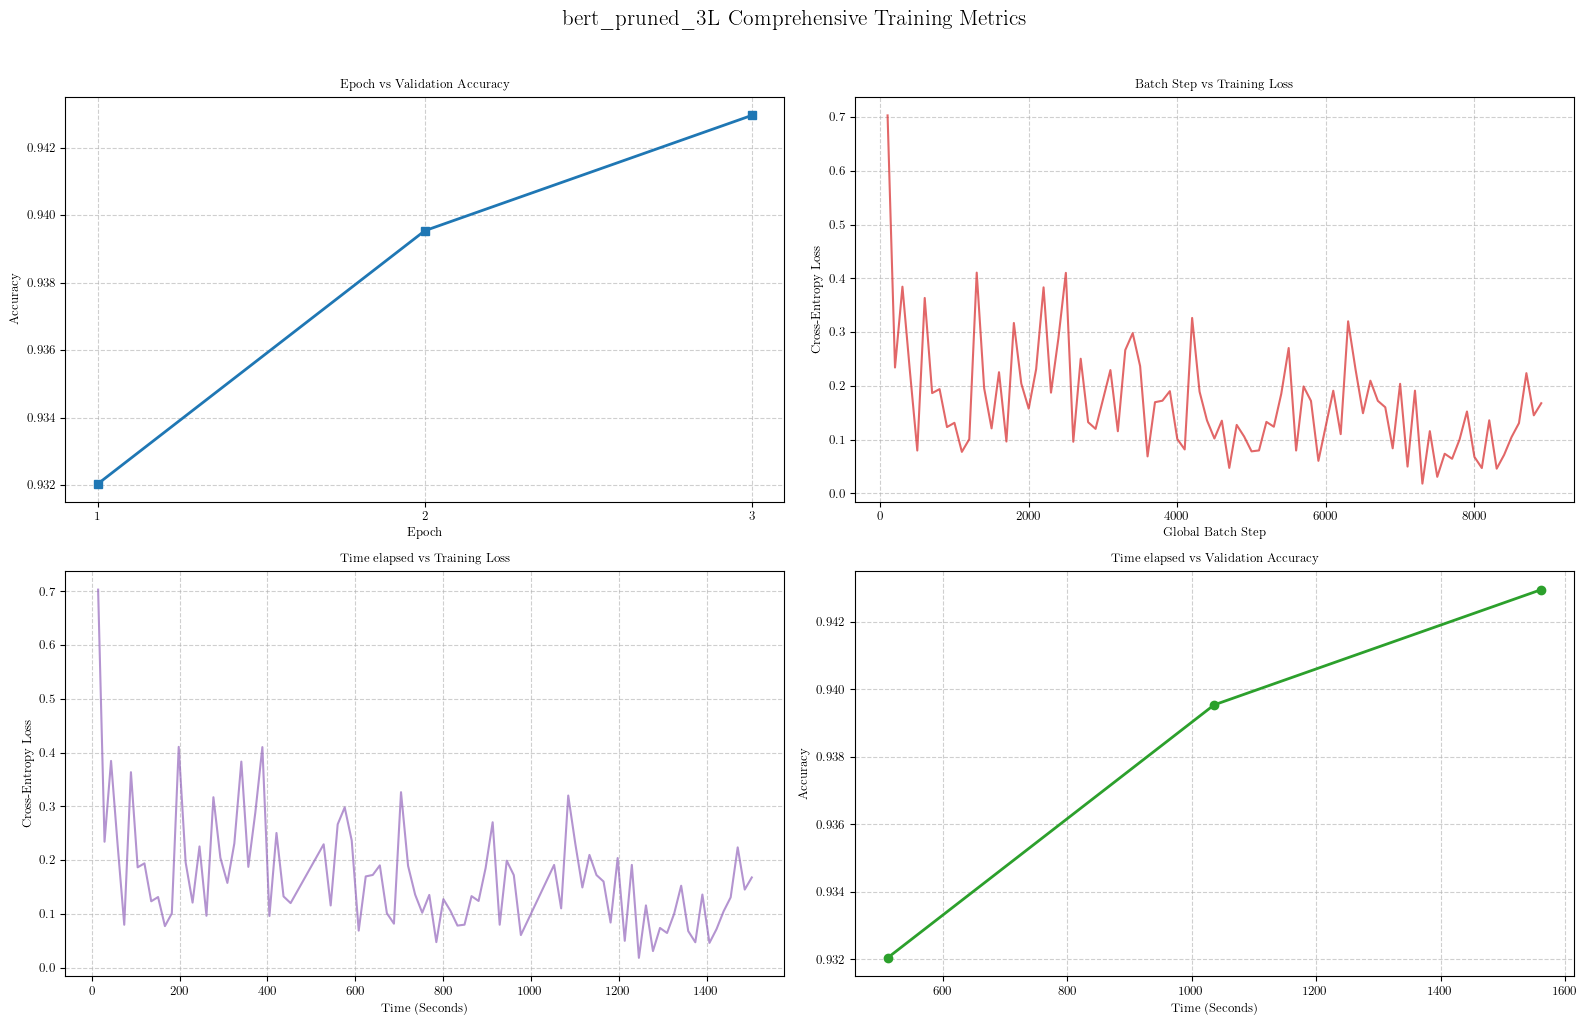


2) VALIDATION
Saved validation run: metrics/bert_pruned_3l_validation_run.npz

=== bert_pruned_3L Validation Metrics ===
Accuracy:  0.9430
Precision: 0.9433
Recall:    0.9430
F1-Score:  0.9429

              precision    recall  f1-score   support

       World       0.96      0.94      0.95      6000
      Sports       0.98      0.99      0.98      6000
    Business       0.93      0.90      0.91      6000
    Sci/Tech       0.90      0.94      0.92      6000

    accuracy                           0.94     24000
   macro avg       0.94      0.94      0.94     24000
weighted avg       0.94      0.94      0.94     24000



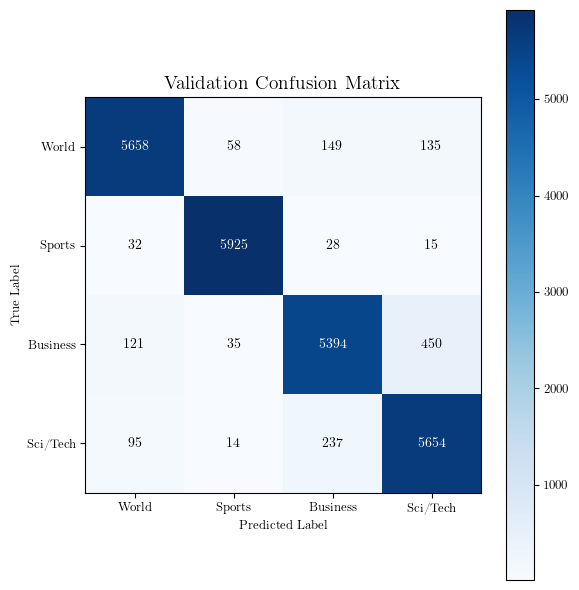


3) PROFILE SUMMARY

PROFILE SUMMARY: bert_pruned_3L

[Model Architecture]
  Total Parameters:       45,694,468
  Trainable Parameters:   45,694,468
  Frozen Parameters:      0
  Trainable %:            100.0%
  Model Size:             174.32 MB

[Inference Performance on Validation Set]
  Inference Device:       cuda
  Total Inference Time:   38.34 seconds
  Samples Processed:      24,000
  Batches Processed:      750
  Throughput:             625.96 samples/sec
  Latency (per sample):   1.598 ms

[Overall Performance Metrics]
  Accuracy:               0.9430
  Precision (weighted):   0.9433
  Recall (weighted):      0.9430
  F1-Score (weighted):    0.9429

[Per-Class Breakdown]
  World        — Accuracy: 0.9430 | Support:  6000
  Sports       — Accuracy: 0.9875 | Support:  6000
  Business     — Accuracy: 0.8990 | Support:  6000
  Sci/Tech     — Accuracy: 0.9423 | Support:  6000

✓ Profile summary saved to: metrics/bert_pruned_3l_profile_summary.json
Saved profile summary JSON: metric

,Text,True Label,Predicted Label,Model Confidence
0,"olympians pursuit of marketing gold begins long before medals & lt ; b & gt ;... & lt ; / b & gt ; - for millions of americans, gymnast paul hamm # 39 ; s fame began only when the broad - shouldered olympian shrugged off a fall in the vaulting competition last week and made an inspired comeback to win gold.",Business,Sports,94.1%
1,"nextel wants better fcc deal - nextel communications inc. is pressing the federal communications commission to revamp its controversial decision giving the cellular company new airwaves, seeking changes that according to",Sci/Tech,Business,76.2%
2,"intel puts its weight behind symbian - intel is building a symbian - based mobile phone, based on nokia # 39 ; s series 60 user interface. the company has not announced a delivery date, but a reference platform should arrive sometime in 2005, intended to",Business,Sci/Tech,98.0%
3,dial 4 - 1 - 1 for cell phone numbers? - washington - - you soon may be able to dial 411 to find a cell phone numbers as well as traditional land - line phone information. six of the seven largest wireless carriers,Business,Sci/Tech,61.9%
4,stakes high for england - england will have a semi - final place in their sights when they face sri lanka in the champions trophy.,World,Sports,87.9%
5,"microsoft still wants eu settlement ( reuters ) - reuters - microsoft corp ' s chief counsel, \ briefing reporters in the lead - up to a european union court \ hearing this week, said on monday he remains hopeful the \ software giant ' s european antitrust case can be settled.",Business,Sci/Tech,66.7%
6,"military snipers learn from competition ( ap ) - ap - corp. eugenio mendoza, a young veteran of the iraq war, had to carry his buddy for 50 yards, scale an 8 - foot wall and crawl through a water - logged tunnel at the 4th international sniper competition, where the challenges are designed to simulate combat scenarios in afghanistan and iraq.",Sports,World,73.7%
7,"fcc denies states control of voip - providers of internet - based phone services, such as overland park - based nuvio corp. and time warner cable, notched a victory tuesday when the federal communications commission said states could not regulate the futuristic service.",Business,Sci/Tech,84.2%
8,"the more the red sox and cubs talk about it, the worse it gets - i # 39 ; m pleased to report that you # 39 ; ve heeded my anguished cry for thoughtful commentary and staved off my insidious plan to write a treatise on keynesian economics.",Sports,Business,87.5%
9,"takenaka says tankan confirms japan # 39 ; s steady economic recovery - the bank of japan # 39 ; s quarterly survey of business confidence confirmed that the world # 39 ; s second - largest economy is recovering at a steady pace, economic and fiscal policy minister heizo takenaka said.",World,Business,78.4%


In [27]:
ultimate_pruned_3L = run_ultimate_analysis(
    model=model_pruned,
    val_loader=val_loader,
    history=history_pruned_3L,
    device=device,
    tokenizer=tokenizer,
    class_names=['World', 'Sports', 'Business', 'Sci/Tech'],
    model_name='bert_pruned_3L',
    analysis_dir='metrics',
    force_validation_run=True, # True so we evaluate the freshly trained model
    hardware_batches=10,
)

#### 1 Layer

In [28]:
# Create the 1-layer model and push it to the GPU
model_pruned = create_pruned_bert(num_layers_to_keep=1, num_labels=4)
model_pruned = model_pruned.to(device)

# Set up the optimizer (using the same learning rate as Task 2c for a fair comparison)
optimizer_pruned = AdamW(model_pruned.parameters(), lr=2e-5)

# Fine-tune the pruned model
history_pruned_1L = train_and_evaluate_tracked(
    model=model_pruned, 
    train_loader=train_loader,   
    val_loader=val_loader,       
    optimizer=optimizer_pruned, 
    epochs=3,
    save_prefix="weigths/bert_pruned_1L" 
)


Loading base BERT and pruning down to 1 layers...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Pruning successful! New parameter count: 31,518,724

Epoch 1/3
-----------------------------------
  Batch 100/3000 | Loss: 1.1589 | Time: 5.2s
  Batch 200/3000 | Loss: 0.6083 | Time: 10.4s
  Batch 300/3000 | Loss: 0.4134 | Time: 15.6s
  Batch 400/3000 | Loss: 0.2274 | Time: 20.8s
  Batch 500/3000 | Loss: 0.2439 | Time: 26.0s
  Batch 600/3000 | Loss: 0.3840 | Time: 31.3s
  Batch 700/3000 | Loss: 0.5083 | Time: 36.6s
  Batch 800/3000 | Loss: 0.0823 | Time: 41.9s
  Batch 900/3000 | Loss: 0.4203 | Time: 47.2s
  Batch 1000/3000 | Loss: 0.3625 | Time: 52.6s
  Batch 1100/3000 | Loss: 0.2452 | Time: 57.9s
  Batch 1200/3000 | Loss: 0.1490 | Time: 63.3s
  Batch 1300/3000 | Loss: 0.1917 | Time: 68.7s
  Batch 1400/3000 | Loss: 0.1868 | Time: 74.2s
  Batch 1500/3000 | Loss: 0.3308 | Time: 79.6s
  Batch 1600/3000 | Loss: 0.3229 | Time: 85.0s
  Batch 1700/3000 | Loss: 0.3663 | Time: 90.5s
  Batch 1800/3000 | Loss: 0.1138 | Time: 96.0s
  Batch 1900/3000 | Loss: 0.1783 | Time: 101.5s
  Batch 2000/3000


ULTIMATE ANALYSIS: bert_pruned_1L

1) TRAINING HISTORY
=== Training History Analysis: bert_pruned_1L ===

[Speed & Duration]
Total Training Time: 9.30 minutes
Average Epoch Time:  185.99 seconds
Average Batch Time:  61.46 ms
Training Throughput: 16.27 batches / second

[Performance Highlights]
Best Val Accuracy:   0.9326 (Achieved in Epoch 3)
Best Val F1-Score:   0.9325 (Achieved in Epoch 3)
Lowest Val Loss:     0.2029 (Achieved in Epoch 3)


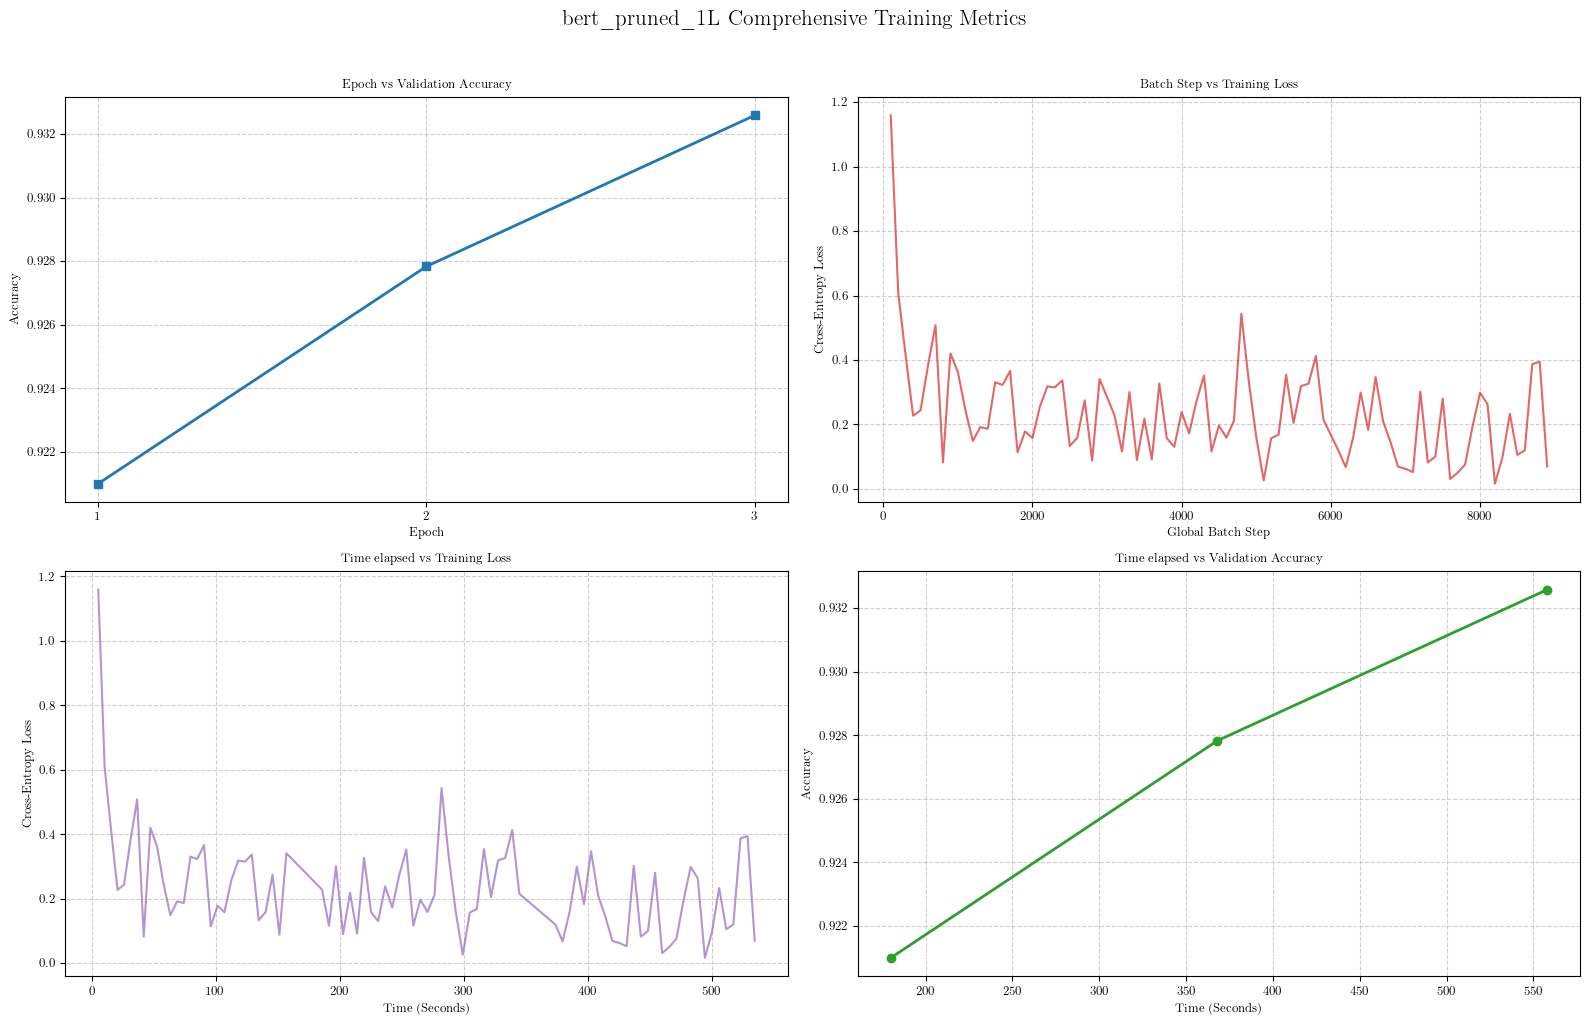


2) VALIDATION
Saved validation run: metrics/bert_pruned_1l_validation_run.npz

=== bert_pruned_1L Validation Metrics ===
Accuracy:  0.9326
Precision: 0.9331
Recall:    0.9326
F1-Score:  0.9325

              precision    recall  f1-score   support

       World       0.95      0.92      0.94      6000
      Sports       0.97      0.99      0.98      6000
    Business       0.92      0.89      0.90      6000
    Sci/Tech       0.89      0.94      0.91      6000

    accuracy                           0.93     24000
   macro avg       0.93      0.93      0.93     24000
weighted avg       0.93      0.93      0.93     24000



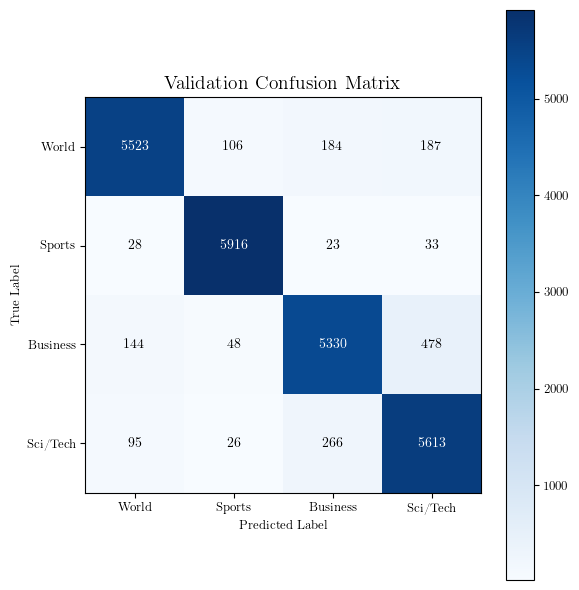


3) PROFILE SUMMARY

PROFILE SUMMARY: bert_pruned_1L

[Model Architecture]
  Total Parameters:       31,518,724
  Trainable Parameters:   31,518,724
  Frozen Parameters:      0
  Trainable %:            100.0%
  Model Size:             120.24 MB

[Inference Performance on Validation Set]
  Inference Device:       cuda
  Total Inference Time:   17.05 seconds
  Samples Processed:      24,000
  Batches Processed:      750
  Throughput:             1407.84 samples/sec
  Latency (per sample):   0.710 ms

[Overall Performance Metrics]
  Accuracy:               0.9326
  Precision (weighted):   0.9331
  Recall (weighted):      0.9326
  F1-Score (weighted):    0.9325

[Per-Class Breakdown]
  World        — Accuracy: 0.9205 | Support:  6000
  Sports       — Accuracy: 0.9860 | Support:  6000
  Business     — Accuracy: 0.8883 | Support:  6000
  Sci/Tech     — Accuracy: 0.9355 | Support:  6000

✓ Profile summary saved to: metrics/bert_pruned_1l_profile_summary.json
Saved profile summary JSON: metri

,Text,True Label,Predicted Label,Model Confidence
0,"olympians pursuit of marketing gold begins long before medals & lt ; b & gt ;... & lt ; / b & gt ; - for millions of americans, gymnast paul hamm # 39 ; s fame began only when the broad - shouldered olympian shrugged off a fall in the vaulting competition last week and made an inspired comeback to win gold.",Business,Sports,99.4%
1,"new device : flying robot - seiko epson hopes the tiny robot will help in security, disaster and rescue and space exploration. also : apple recalls batteries from its 15 - inch powerbook g4 laptops hellip ;. sony unveils eight new flat - screen tvs hellip ;. and more.",Business,Sci/Tech,93.2%
2,"nextel wants better fcc deal - nextel communications inc. is pressing the federal communications commission to revamp its controversial decision giving the cellular company new airwaves, seeking changes that according to",Sci/Tech,Business,65.0%
3,"intel puts its weight behind symbian - intel is building a symbian - based mobile phone, based on nokia # 39 ; s series 60 user interface. the company has not announced a delivery date, but a reference platform should arrive sometime in 2005, intended to",Business,Sci/Tech,97.9%
4,dial 4 - 1 - 1 for cell phone numbers? - washington - - you soon may be able to dial 411 to find a cell phone numbers as well as traditional land - line phone information. six of the seven largest wireless carriers,Business,Sci/Tech,70.5%
5,stakes high for england - england will have a semi - final place in their sights when they face sri lanka in the champions trophy.,World,Sports,97.3%
6,"microsoft still wants eu settlement ( reuters ) - reuters - microsoft corp ' s chief counsel, \ briefing reporters in the lead - up to a european union court \ hearing this week, said on monday he remains hopeful the \ software giant ' s european antitrust case can be settled.",Business,Sci/Tech,76.6%
7,"military snipers learn from competition ( ap ) - ap - corp. eugenio mendoza, a young veteran of the iraq war, had to carry his buddy for 50 yards, scale an 8 - foot wall and crawl through a water - logged tunnel at the 4th international sniper competition, where the challenges are designed to simulate combat scenarios in afghanistan and iraq.",Sports,Sci/Tech,57.2%
8,khan guarantees medal - british lightweight amir khan beats south korean baik jong - sub to secure at least a bronze medal.,Sports,World,95.1%
9,"microsoft deletes more antitrust opponents - after years of expensive litigation aimed at weakening its hold on the software market, microsoft ( msft : nasdaq - news - research ) is on the verge of settling with nearly all of its opponents.",Business,Sci/Tech,52.4%


In [29]:
ultimate_pruned_1L = run_ultimate_analysis(
    model=model_pruned,
    val_loader=val_loader,
    history=history_pruned_1L,
    device=device,
    tokenizer=tokenizer,
    class_names=['World', 'Sports', 'Business', 'Sci/Tech'],
    model_name='bert_pruned_1L',
    analysis_dir='metrics',
    force_validation_run=True, # True so we evaluate the freshly trained model
    hardware_batches=10,
)

### Utils

In [ ]:
def load_pruned_bert_model(checkpoint_path, num_layers_to_keep, num_labels=4):
    """Load a pruned BERT checkpoint onto the active device."""
    model = create_pruned_bert(num_layers_to_keep=num_layers_to_keep, num_labels=num_labels)
    state_dict = torch.load(checkpoint_path, map_location=device, weights_only=True)
    model.load_state_dict(state_dict)
    model = model.to(device)
    model.eval()
    return model

## Task 2g

### Legacy 

In [31]:

def enable_dropout(model):
    """
    Forces all Dropout layers to be active, even if the model is in eval() mode.
    """
    for m in model.modules():
        if m.__class__.__name__.startswith('Dropout'):
            m.train()

def predict_with_uncertainty(model, dataloader, device, num_mc_passes=20):
    """
    Runs MC Dropout to get predictions and uncertainty scores (Predictive Entropy).
    """
    print(f"Running MC Dropout with {num_mc_passes} forward passes per sample...")
    
    # 1. Put model in eval mode, but force dropout to stay ON
    model.eval()
    enable_dropout(model)
    
    all_mean_probs = []
    all_uncertainties = []
    all_labels = []
    all_preds = []
    
    with torch.no_grad():
        for step, batch in enumerate(dataloader):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            # 2. Run the SAME batch multiple times
            # Shape will be: [num_mc_passes, batch_size, num_classes]
            mc_outputs = []
            for _ in range(num_mc_passes):
                outputs = model(input_ids, attention_mask=attention_mask)
                # Convert raw logits to probabilities (0.0 to 1.0)
                probs = F.softmax(outputs.logits, dim=1)
                mc_outputs.append(probs)
                
            # Stack the lists into a single PyTorch tensor
            mc_outputs = torch.stack(mc_outputs)
            
            # 3. Calculate Mean and Uncertainty
            # Average the probabilities across all 20 passes
            mean_probs = mc_outputs.mean(dim=0)
            
            # The final prediction is the class with the highest average probability
            preds = torch.argmax(mean_probs, dim=1)
            
            # Calculate Predictive Entropy (Standard measure of uncertainty)
            # Higher entropy = Model is highly uncertain
            # Lower entropy  = Model is highly confident
            mean_probs_np = mean_probs.cpu().numpy()
            uncertainty = entropy(mean_probs_np, axis=1)
            
            # Store results
            all_mean_probs.extend(mean_probs_np)
            all_uncertainties.extend(uncertainty)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            
            if step % 50 == 0:
                print(f"  Processed batch {step}/{len(dataloader)}")
                
    print("MC Dropout evaluation complete!")
    return np.array(all_preds), np.array(all_labels), np.array(all_uncertainties)

### Functions for loading, savin and evaluating MC dropout models

In [16]:
def save_mc_dropout_run(run_data, run_path):
    """Save MC Dropout outputs to a compressed .npz cache."""
    os.makedirs(os.path.dirname(run_path) or '.', exist_ok=True)
    np.savez_compressed(run_path, **run_data)
    print(f'Saved MC Dropout run: {run_path}')


def load_mc_dropout_run(run_path):
    """Load MC Dropout outputs from a compressed .npz cache."""
    data = np.load(run_path)
    return {key: data[key] for key in data.files}


def run_mc_dropout_validation(
    evaluator,
    dataloader,
    num_mc_passes=20,
    run_path=None,
    force_run=False,
    max_batches=None,
    progress_every=10,
):
    """Run MC Dropout on a validation loader and optionally cache the results."""
    if run_path and (not force_run) and os.path.exists(run_path):
        print(f'Loaded cached MC Dropout run: {run_path}')
        return load_mc_dropout_run(run_path)

    model = evaluator.model
    device = evaluator.device
    model.eval()
    evaluator._enable_dropout(model)

    all_preds = []
    all_labels = []
    all_uncertainties = []
    all_confidences = []
    all_margins = []
    all_mean_probs = []
    all_input_ids = []
    sample_indices = []
    sample_offset = 0

    with torch.no_grad():
        for batch_idx, batch in enumerate(dataloader, start=1):
            if max_batches is not None and batch_idx > max_batches:
                break

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            mc_probs = []
            for _ in range(num_mc_passes):
                outputs = model(input_ids, attention_mask=attention_mask)
                probs = F.softmax(outputs.logits, dim=-1)
                mc_probs.append(probs)

            mc_probs = torch.stack(mc_probs, dim=0)
            mean_probs = mc_probs.mean(dim=0)
            top2 = torch.topk(mean_probs, k=2, dim=1).values
            preds = torch.argmax(mean_probs, dim=1)
            uncertainty = entropy(mean_probs.detach().cpu().numpy(), axis=1)
            confidence = top2[:, 0].detach().cpu().numpy()
            margin = (top2[:, 0] - top2[:, 1]).detach().cpu().numpy()

            batch_size = labels.shape[0]
            all_preds.append(preds.detach().cpu().numpy())
            all_labels.append(labels.detach().cpu().numpy())
            all_uncertainties.append(uncertainty.astype(np.float32))
            all_confidences.append(confidence.astype(np.float32))
            all_margins.append(margin.astype(np.float32))
            all_mean_probs.append(mean_probs.detach().cpu().numpy().astype(np.float32))
            all_input_ids.append(input_ids.detach().cpu().numpy().astype(np.int32))
            sample_indices.append(np.arange(sample_offset, sample_offset + batch_size, dtype=np.int64))
            sample_offset += batch_size

            if progress_every and batch_idx % progress_every == 0:
                if max_batches is None:
                    print(f'Processed {batch_idx} validation batches')
                else:
                    print(f'Processed {batch_idx}/{max_batches} validation batches')

    run_data = {
        'preds': np.concatenate(all_preds) if all_preds else np.empty(0, dtype=np.int64),
        'labels': np.concatenate(all_labels) if all_labels else np.empty(0, dtype=np.int64),
        'uncertainties': np.concatenate(all_uncertainties) if all_uncertainties else np.empty(0, dtype=np.float32),
        'confidences': np.concatenate(all_confidences) if all_confidences else np.empty(0, dtype=np.float32),
        'margins': np.concatenate(all_margins) if all_margins else np.empty(0, dtype=np.float32),
        'mean_probs': np.concatenate(all_mean_probs) if all_mean_probs else np.empty((0, len(evaluator.class_names)), dtype=np.float32),
        'input_ids': np.concatenate(all_input_ids) if all_input_ids else np.empty((0, 0), dtype=np.int32),
        'sample_indices': np.concatenate(sample_indices) if sample_indices else np.empty(0, dtype=np.int64),
    }

    if run_path:
        save_mc_dropout_run(run_data, run_path)

    return run_data


def build_human_review_queue(
    run_data,
    tokenizer,
    class_names,
    top_k=20,
    review_percentile=90,
    low_confidence_threshold=0.60,
    margin_threshold=0.15,
):
    """Select the most uncertain predictions for human review."""
    uncertainties = run_data['uncertainties']
    preds = run_data['preds']
    labels = run_data['labels']
    mean_probs = run_data['mean_probs']
    input_ids = run_data['input_ids']

    review_threshold = np.quantile(uncertainties, review_percentile / 100.0)
    candidate_indices = np.where(uncertainties >= review_threshold)[0]
    candidate_index_set = set(candidate_indices.tolist())

    if candidate_indices.size < top_k:
        candidate_indices = np.argsort(uncertainties)[-top_k:]
    else:
        candidate_indices = candidate_indices[np.argsort(uncertainties[candidate_indices])[::-1]]

    review_rows = []
    for rank, idx in enumerate(candidate_indices[:top_k], start=1):
        probs = mean_probs[idx]
        top2_idx = np.argsort(probs)[-2:][::-1]
        top1 = int(top2_idx[0])
        top2 = int(top2_idx[1])
        top1_prob = float(probs[top1])
        top2_prob = float(probs[top2])
        margin = top1_prob - top2_prob
        text = tokenizer.decode(input_ids[idx].tolist(), skip_special_tokens=True)

        reasons = []
        if idx in candidate_index_set:
            reasons.append(f'entropy >= {review_percentile}th percentile')
        if top1_prob < low_confidence_threshold:
            reasons.append('low top-class probability')
        if margin < margin_threshold:
            reasons.append('top-2 classes are close')
        if preds[idx] != labels[idx]:
            reasons.append('prediction is wrong')

        review_rows.append({
            'rank': rank,
            'sample_index': int(run_data['sample_indices'][idx]),
            'entropy': float(uncertainties[idx]),
            'confidence': top1_prob,
            'margin': margin,
            'predicted_label': class_names[int(preds[idx])],
            'true_label': class_names[int(labels[idx])],
            'top_2_classes': f'{class_names[top1]} vs {class_names[top2]}',
            'top_2_probs': f'{top1_prob:.3f} / {top2_prob:.3f}',
            'selection_basis': 'thresholded uncertainty' if idx in candidate_index_set else 'top-k fallback',
            'why_flagged': '; '.join(reasons) if reasons else 'selected from highest-uncertainty fallback',
            'article_text': text,
        })

    review_df = pd.DataFrame(review_rows)
    return review_df, review_threshold


def plot_mc_dropout_diagnostics(run_data, review_threshold=None, title='MC Dropout Uncertainty Diagnostics'):
    """Plot uncertainty separation for correct and wrong predictions."""
    preds = run_data['preds']
    labels = run_data['labels']
    uncertainties = run_data['uncertainties']

    correct_uncertainties = uncertainties[preds == labels]
    wrong_uncertainties = uncertainties[preds != labels]

    fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))

    plot_density = bool(correct_uncertainties.size and wrong_uncertainties.size)
    if correct_uncertainties.size:
        axs[0].hist(correct_uncertainties, bins=40, alpha=0.65, color='tab:green', density=plot_density, label='Correct')
    if wrong_uncertainties.size:
        axs[0].hist(wrong_uncertainties, bins=40, alpha=0.65, color='tab:red', density=plot_density, label='Wrong')
    if review_threshold is not None:
        axs[0].axvline(review_threshold, color='black', linestyle='--', linewidth=2, label='Review threshold')
    axs[0].set_title('Entropy distribution')
    axs[0].set_xlabel('Predictive entropy')
    axs[0].set_ylabel('Density' if plot_density else 'Count')
    axs[0].legend()
    axs[0].grid(True, linestyle='--', alpha=0.4)

    axs[1].scatter(run_data['confidences'], uncertainties, c=np.where(preds == labels, 'tab:blue', 'tab:orange'), alpha=0.55, s=16)
    axs[1].set_title('Confidence vs uncertainty')
    axs[1].set_xlabel('Max mean probability')
    axs[1].set_ylabel('Predictive entropy')
    axs[1].grid(True, linestyle='--', alpha=0.4)

    fig.suptitle(title, fontweight='bold')
    fig.tight_layout()
    plt.show()


### Evaluation

In [ ]:
MODEL_NAME = 'bert_pruned_6L'
NUM_LAYERS_TO_KEEP = 6
CHECKPOINT_PATH = 'weigths/bert_pruned_6L_epoch_3.pt'
NUM_MC_PASSES = 20
MAX_BATCHES = None  # Set to an integer for a partial validation run.
TOP_K = 10

RUN_PATH = f"metrics/{MODEL_NAME}_mc_dropout_passes{NUM_MC_PASSES}_batches{'all' if MAX_BATCHES is None else MAX_BATCHES}.npz"

model = load_pruned_bert_model(
    checkpoint_path=CHECKPOINT_PATH,
    num_layers_to_keep=NUM_LAYERS_TO_KEEP,
    num_labels=4,
)

evaluator = UniversalEvaluator(
    model=model,
    device=device,
    tokenizer=tokenizer,
    class_names=['World', 'Sports', 'Business', 'Sci/Tech'],
)

mc_run = run_mc_dropout_validation(
    evaluator=evaluator,
    dataloader=val_loader,
    num_mc_passes=NUM_MC_PASSES,
    run_path=RUN_PATH,
    force_run=False,
    max_batches=MAX_BATCHES,
    progress_every=10,
)

print(f"Validation samples processed: {len(mc_run['labels'])}")
print(f"Average predictive entropy: {mc_run['uncertainties'].mean():.4f}")
print(f"Average max class probability: {mc_run['confidences'].mean():.4f}")
print(f"Average top-2 margin: {mc_run['margins'].mean():.4f}")

Loading base BERT and pruning down to 6 layers...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Pruning successful! New parameter count: 66,958,084
Processed 10 validation batches
Processed 20 validation batches
Processed 30 validation batches
Processed 40 validation batches
Processed 50 validation batches
Processed 60 validation batches
Processed 70 validation batches
Processed 80 validation batches
Processed 90 validation batches
Processed 100 validation batches
Processed 110 validation batches
Processed 120 validation batches
Processed 130 validation batches
Processed 140 validation batches
Processed 150 validation batches
Processed 160 validation batches
Processed 170 validation batches
Processed 180 validation batches
Processed 190 validation batches
Processed 200 validation batches
Processed 210 validation batches
Processed 220 validation batches
Processed 230 validation batches
Processed 240 validation batches
Processed 250 validation batches
Processed 260 validation batches
Processed 270 validation batches
Processed 280 validation batches
Processed 290 validation batches


Review threshold (90th percentile entropy): 0.4093


,rank,sample_index,entropy,confidence,margin,predicted_label,true_label,top_2_classes,top_2_probs,selection_basis,why_flagged
0,1,8422,1.369442,0.304114,0.021309,World,World,World vs Business,0.304 / 0.283,thresholded uncertainty,entropy >= 90th percentile; low top-class prob...
1,2,23978,1.351648,0.365222,0.139778,World,Business,World vs Sports,0.365 / 0.225,thresholded uncertainty,entropy >= 90th percentile; low top-class prob...
2,3,18336,1.347265,0.376417,0.165588,Sports,World,Sports vs World,0.376 / 0.211,thresholded uncertainty,entropy >= 90th percentile; low top-class prob...
3,4,11976,1.337420,0.378984,0.146214,Sci/Tech,World,Sci/Tech vs Sports,0.379 / 0.233,thresholded uncertainty,entropy >= 90th percentile; low top-class prob...
4,5,4610,1.326257,0.400780,0.173603,Sports,Sci/Tech,Sports vs Sci/Tech,0.401 / 0.227,thresholded uncertainty,entropy >= 90th percentile; low top-class prob...
5,6,7043,1.324257,0.340267,0.033047,Sci/Tech,Sports,Sci/Tech vs Sports,0.340 / 0.307,thresholded uncertainty,entropy >= 90th percentile; low top-class prob...
6,7,18032,1.323344,0.338035,0.047068,World,World,World vs Sports,0.338 / 0.291,thresholded uncertainty,entropy >= 90th percentile; low top-class prob...
7,8,22045,1.316189,0.362468,0.098073,Sports,Sports,Sports vs Sci/Tech,0.362 / 0.264,thresholded uncertainty,entropy >= 90th percentile; low top-class prob...
8,9,7586,1.303628,0.380146,0.067895,World,Business,World vs Sci/Tech,0.380 / 0.312,thresholded uncertainty,entropy >= 90th percentile; low top-class prob...
9,10,22903,1.282593,0.364278,0.014650,Sci/Tech,World,Sci/Tech vs Business,0.364 / 0.350,thresholded uncertainty,entropy >= 90th percentile; low top-class prob...



Rank 1 | entropy=1.3694 | confidence=0.3041 | margin=0.0213
Predicted: World | True: World
Selection basis: thresholded uncertainty
Why flagged: entropy >= 90th percentile; low top-class probability; top-2 classes are close
Article text:
minister stubs out smoke policy - the government # 39 ; s plans for a partial ban on smoking in public places seems to have fallen far short of what has been proposed by liverpool city council.

Rank 2 | entropy=1.3516 | confidence=0.3652 | margin=0.1398
Predicted: World | True: Business
Selection basis: thresholded uncertainty
Why flagged: entropy >= 90th percentile; low top-class probability; top-2 classes are close; prediction is wrong
Article text:
a fragmented look at the business of multiculturalism - my friends laugh at me for watching ' ' passions, quot ; the campy daytime drama about occult doings in a new england hamlet. but my favorite soap is cutting - edge : it has been praised for featuring a mexican - american family, a rare dash of col

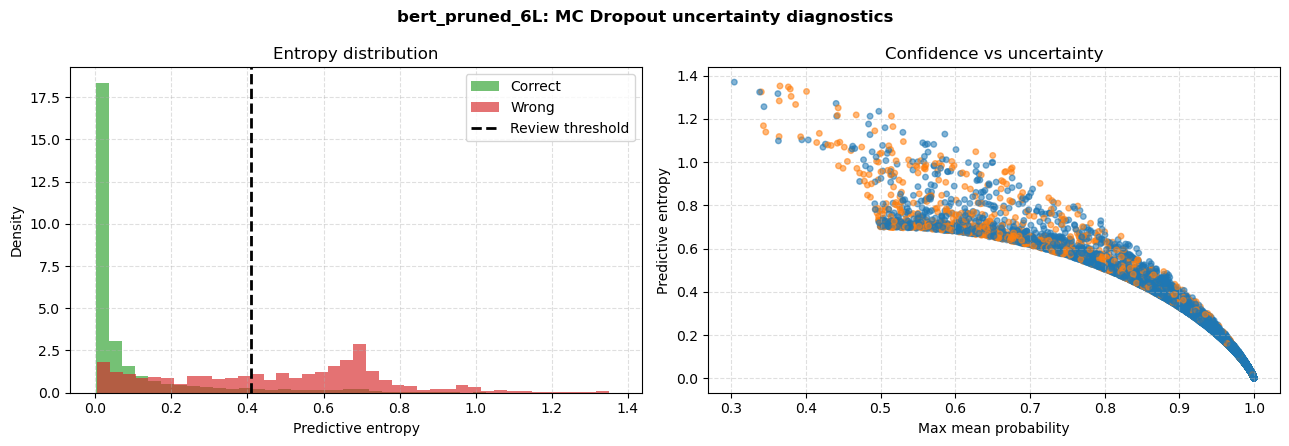

In [20]:
review_df, review_threshold = build_human_review_queue(
    mc_run,
    tokenizer=tokenizer,
    class_names=evaluator.class_names,
    top_k=TOP_K,
    review_percentile=90,
    low_confidence_threshold=0.60,
    margin_threshold=0.15,
)

print(f"Review threshold (90th percentile entropy): {review_threshold:.4f}")
display(review_df[[
    'rank',
    'sample_index',
    'entropy',
    'confidence',
    'margin',
    'predicted_label',
    'true_label',
    'top_2_classes',
    'top_2_probs',
    'selection_basis',
    'why_flagged',
]])

for _, row in review_df.head(10).iterrows():
    print('\n' + '=' * 100)
    print(f"Rank {int(row['rank'])} | entropy={row['entropy']:.4f} | confidence={row['confidence']:.4f} | margin={row['margin']:.4f}")
    print(f"Predicted: {row['predicted_label']} | True: {row['true_label']}")
    print(f"Selection basis: {row['selection_basis']}")
    print(f"Why flagged: {row['why_flagged']}")
    print('Article text:')
    print(row['article_text'])

plot_mc_dropout_diagnostics(
    mc_run,
    review_threshold=review_threshold,
    title=f"{MODEL_NAME}: MC Dropout uncertainty diagnostics",
)

### Plotting

In [ ]:
MODEL_NAME = 'bert_pruned_6L'
NUM_LAYERS_TO_KEEP = 6
CHECKPOINT_PATH = 'weigths/bert_pruned_6L_epoch_3.pt'
NUM_MC_PASSES = 20
MAX_BATCHES = None  # Set to an integer for a partial validation run.
TOP_K = 10

RUN_PATH = f"metrics/{MODEL_NAME}_mc_dropout_passes{NUM_MC_PASSES}_batches{'all' if MAX_BATCHES is None else MAX_BATCHES}.npz"

model = load_pruned_bert_model(
    checkpoint_path=CHECKPOINT_PATH,
    num_layers_to_keep=NUM_LAYERS_TO_KEEP,
    num_labels=4,
)

evaluator = UniversalEvaluator(
    model=model,
    device=device,
    tokenizer=tokenizer,
    class_names=['World', 'Sports', 'Business', 'Sci/Tech'],
)

mc_run = run_mc_dropout_validation(
    evaluator=evaluator,
    dataloader=val_loader,
    num_mc_passes=NUM_MC_PASSES,
    run_path=RUN_PATH,
    force_run=False,
    max_batches=MAX_BATCHES,
    progress_every=10,
)

def plot_mc_dropout_diagnostics(run_data, review_threshold=None, title='MC Dropout Uncertainty Diagnostics'):
    """Plot uncertainty separation for correct and wrong predictions."""
    preds = run_data['preds']
    labels = run_data['labels']
    uncertainties = run_data['uncertainties']

    correct_uncertainties = uncertainties[preds == labels]
    wrong_uncertainties = uncertainties[preds != labels]

    fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))

    plot_density = bool(correct_uncertainties.size and wrong_uncertainties.size)
    if correct_uncertainties.size:
        axs[0].hist(correct_uncertainties, bins=40, alpha=0.65, color='tab:green', density=plot_density, label='Correct')
    if wrong_uncertainties.size:
        axs[0].hist(wrong_uncertainties, bins=40, alpha=0.65, color='tab:red', density=plot_density, label='Wrong')
    if review_threshold is not None:
        axs[0].axvline(review_threshold, color='black', linestyle='--', linewidth=2, label='Review threshold')
    axs[0].set_title('Entropy distribution')
    axs[0].set_xlabel('Predictive entropy')
    axs[0].set_ylabel('Density' if plot_density else 'Count')
    axs[0].legend()
    axs[0].grid(True, linestyle='--', alpha=0.4)

    axs[1].scatter(run_data['confidences'], uncertainties, c=np.where(preds == labels, 'tab:blue', 'tab:orange'), alpha=0.55, s=16)
    axs[1].set_title('Confidence vs uncertainty')
    axs[1].set_xlabel('Max mean probability')
    axs[1].set_ylabel('Predictive entropy')
    axs[1].grid(True, linestyle='--', alpha=0.4)

    fig.suptitle(title, fontweight='bold')
    fig.tight_layout()
    plt.show()